# GRAND PROJET_MACHINE LEARNING_SDA
SIDIBE OUMOU MALIKA & NANDJUI BLESSON NAOMI

# THEME: PREDICTION CUSTOMER CHURN

## QUESTION DE RECHERCHE : Quelles sont les déterminants qui influencent le plus le churn ?

### Importation des librairies 

In [1]:
# Importation des Librairies et Outils
import numpy as np
import pandas as pd
import itertools
import re
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import warnings

# Techniques pour les Données Déséquilibrées
from collections import Counter
from sklearn.datasets import make_classification

# Modélisation de Réseaux de Neurones Artificiels
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Dropout

# Analyse Statistique
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Visualisation des Données
import plotly.express as px
import plotly.graph_objects as go
import scikitplot as skplt
import sweetviz as sv
from IPython.display import Image, HTML
import lazypredict
from lazypredict.Supervised import LazyClassifier

# Modélisation de l'Apprentissage Automatique
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedShuffleSplit, RepeatedStratifiedKFold, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Sélection de Caractéristiques et Réduction de Dimensionnalité
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif, RFE, RFECV, VarianceThreshold
from boruta import BorutaPy

# Prétraitement des Données
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Interprétabilité du Modèle
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
 # Imbalanced Data Techniques
import imblearn
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
# Évaluation des Modèles
from sklearn import metrics
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, accuracy_score, confusion_matrix, precision_recall_curve, average_precision_score, auc, roc_curve, roc_auc_score

# Création de Pipelines pour les Transformations Categoriques
categorical_transformer_low = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("encoding", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

categorical_transformer_high = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("encoding", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)


ModuleNotFoundError: No module named 'tensorflow'

In [19]:
base = pd.read_csv(r"C:/Users/oumou/OneDrive/Bureau/Projet _ML/resilation des clients.csv", sep=";")


### Data Info

In [20]:
# Dimention du Dataframe
base.shape

(7043, 21)

In [21]:
print(base.columns)


Index(['customer_id', 'gender', 'senior_citizen', 'married', 'dependents',
       'tenure_in_months', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection_plan', 'premium_tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charge', 'total_charges', 'churn_value'],
      dtype='object')


In [22]:
# information sur notre base de données
print(base.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             7043 non-null   object 
 1   gender                  7043 non-null   object 
 2   senior_citizen          7043 non-null   int64  
 3   married                 7043 non-null   object 
 4   dependents              7043 non-null   object 
 5   tenure_in_months        7043 non-null   int64  
 6   phone_service           7043 non-null   object 
 7   multiple_lines          7043 non-null   object 
 8   internet_service        7043 non-null   object 
 9   online_security         7043 non-null   object 
 10  online_backup           7043 non-null   object 
 11  device_protection_plan  7043 non-null   object 
 12  premium_tech_support    7043 non-null   object 
 13  streaming_tv            7043 non-null   object 
 14  streaming_movies        7043 non-null   

In [23]:
# verifions les types de données 
print(base.dtypes)


customer_id                object
gender                     object
senior_citizen              int64
married                    object
dependents                 object
tenure_in_months            int64
phone_service              object
multiple_lines             object
internet_service           object
online_security            object
online_backup              object
device_protection_plan     object
premium_tech_support       object
streaming_tv               object
streaming_movies           object
contract                   object
paperless_billing          object
payment_method             object
monthly_charge            float64
total_charges              object
churn_value                object
dtype: object


### Visualisation du dataframe

In [24]:
base.head()

,customer_id,gender,senior_citizen,married,dependents,tenure_in_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charge,total_charges,churn_value
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
base.shape

(7043, 21)

<Axes: >

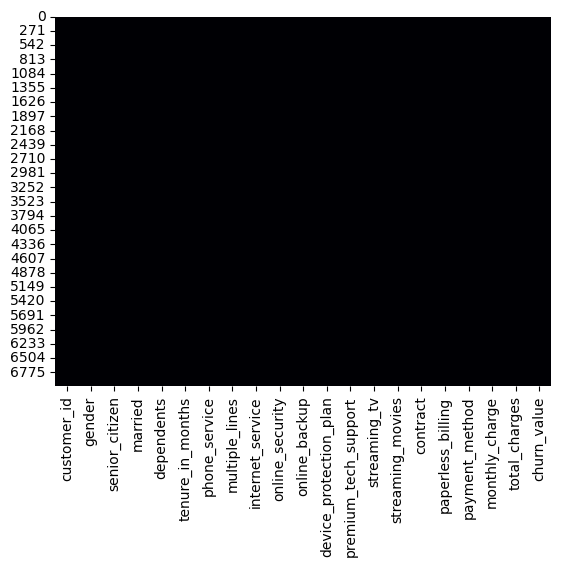

In [26]:
# vérification des valeurs manquantes

sns.heatmap(base.isnull(), cmap='magma', cbar=False)

### Aucune donnée manquante dans cet ensemble de données 

In [27]:
# information statistique 
base.describe().T 

,count,mean,std,min,25%,50%,75%,max
senior_citizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure_in_months,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
monthly_charge,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75


Nous constatons que environs 16.2% des individus seniors, avec une majorité d'entre eux ne l'étant pas,
la durée moyenne du contrat est de 32 mois, avec une large variabilité et certains clients restant jusqu'à 72 mois.
et les charges mensuelles moyennes sont de 64.76 unités, avec des variations importantes allant de 18.25 à 118.75 unités.
Allons plus loins pour obtenir une vue complète de notre modèle.

### prétraitement 

In [28]:
# Convertissons des variables 
# Encodage 
base_copy = base.copy(deep=True)

# Liste des colonnes catégorielles à encoder (doit être une liste de noms de colonnes)
categorical_columns = [
    'gender', 'senior_citizen', 'married', 'dependents',
    'phone_service', 'multiple_lines', 'internet_service', 'online_security',
    'online_backup', 'device_protection_plan', 'premium_tech_support', 
    'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 
    'payment_method',  'churn_value'
]

# Création du LabelEncoder
le = LabelEncoder()

# Application de l'encodage
for col in categorical_columns:
    if col in base_copy.columns:
        base_copy[col] = le.fit_transform(base_copy[col])
        print(f'{col} (avant encodage) : {base[col].unique()}')
        print(f'{col} (après encodage) : {base_copy[col].unique()}\n')
    else:
        print(f"Colonne '{col}' non trouvée dans le DataFrame.\n")


gender (avant encodage) : ['Female' 'Male']
gender (après encodage) : [0 1]

senior_citizen (avant encodage) : [0 1]
senior_citizen (après encodage) : [0 1]

married (avant encodage) : ['Yes' 'No']
married (après encodage) : [1 0]

dependents (avant encodage) : ['No' 'Yes']
dependents (après encodage) : [0 1]

phone_service (avant encodage) : ['No' 'Yes']
phone_service (après encodage) : [0 1]

multiple_lines (avant encodage) : ['No phone service' 'No' 'Yes']
multiple_lines (après encodage) : [1 0 2]

internet_service (avant encodage) : ['DSL' 'Fiber optic' 'No']
internet_service (après encodage) : [0 1 2]

online_security (avant encodage) : ['No' 'Yes' 'No internet service']
online_security (après encodage) : [0 2 1]

online_backup (avant encodage) : ['Yes' 'No' 'No internet service']
online_backup (après encodage) : [2 0 1]

device_protection_plan (avant encodage) : ['No' 'Yes' 'No internet service']
device_protection_plan (après encodage) : [0 2 1]

premium_tech_support (avant encod

In [29]:
# Convertion de'TotalCharges'en numérique
base_copy['total_charges'] = pd.to_numeric(base_copy['total_charges'], errors='coerce')


In [30]:
# information après Encodage
print(base_copy.dtypes)


customer_id                object
gender                      int32
senior_citizen              int64
married                     int32
dependents                  int32
tenure_in_months            int64
phone_service               int32
multiple_lines              int32
internet_service            int32
online_security             int32
online_backup               int32
device_protection_plan      int32
premium_tech_support        int32
streaming_tv                int32
streaming_movies            int32
contract                    int32
paperless_billing           int32
payment_method              int32
monthly_charge            float64
total_charges             float64
churn_value                 int32
dtype: object


In [31]:
# Affichage des 5 premières lignes du DataFrame encodé
display(base_copy.head())

,customer_id,gender,senior_citizen,married,dependents,tenure_in_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charge,total_charges,churn_value
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [32]:
# Remplacement des valeurs manquantes dans 'total_charges' par la moyenne de la colonne
base_copy['total_charges'].fillna(base_copy['total_charges'].mean(), inplace=True)

In [33]:
# Statistique descriptive transposée du DataFrame encodé
base_copy.describe().T


,count,mean,std,min,25%,50%,75%,max
gender,7043.00,0.50,0.50,0.00,0.00,1.00,1.00,1.00
senior_citizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
married,7043.00,0.48,0.50,0.00,0.00,0.00,1.00,1.00
dependents,7043.00,0.30,0.46,0.00,0.00,0.00,1.00,1.00
tenure_in_months,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
phone_service,7043.00,0.90,0.30,0.00,1.00,1.00,1.00,1.00
multiple_lines,7043.00,0.94,0.95,0.00,0.00,1.00,2.00,2.00
internet_service,7043.00,0.87,0.74,0.00,0.00,1.00,1.00,2.00
online_security,7043.00,0.79,0.86,0.00,0.00,1.00,2.00,2.00
online_backup,7043.00,0.91,0.88,0.00,0.00,1.00,2.00,2.00


Les resultats de cette statistique montrent que la majorité des clients utilisent divers services et ont des caractéristiques variées. Par exemple, presque tous ont un service téléphonique, mais les frais mensuels et les charges totales varient beaucoup on constate aussi que Environ 27% des clients ont quitté le service de télécommunication. Aprés cette analyse on vas ensuite identifier des modèles et des tendances, utiles pour analyse des comportements des clients 

### Analyse Exploratoire des Données

In [35]:
# Sauvegarde du rapport dans un fichier HTML
data_report.show_html('base_copy_report.html')

NameError: name 'data_report' is not defined

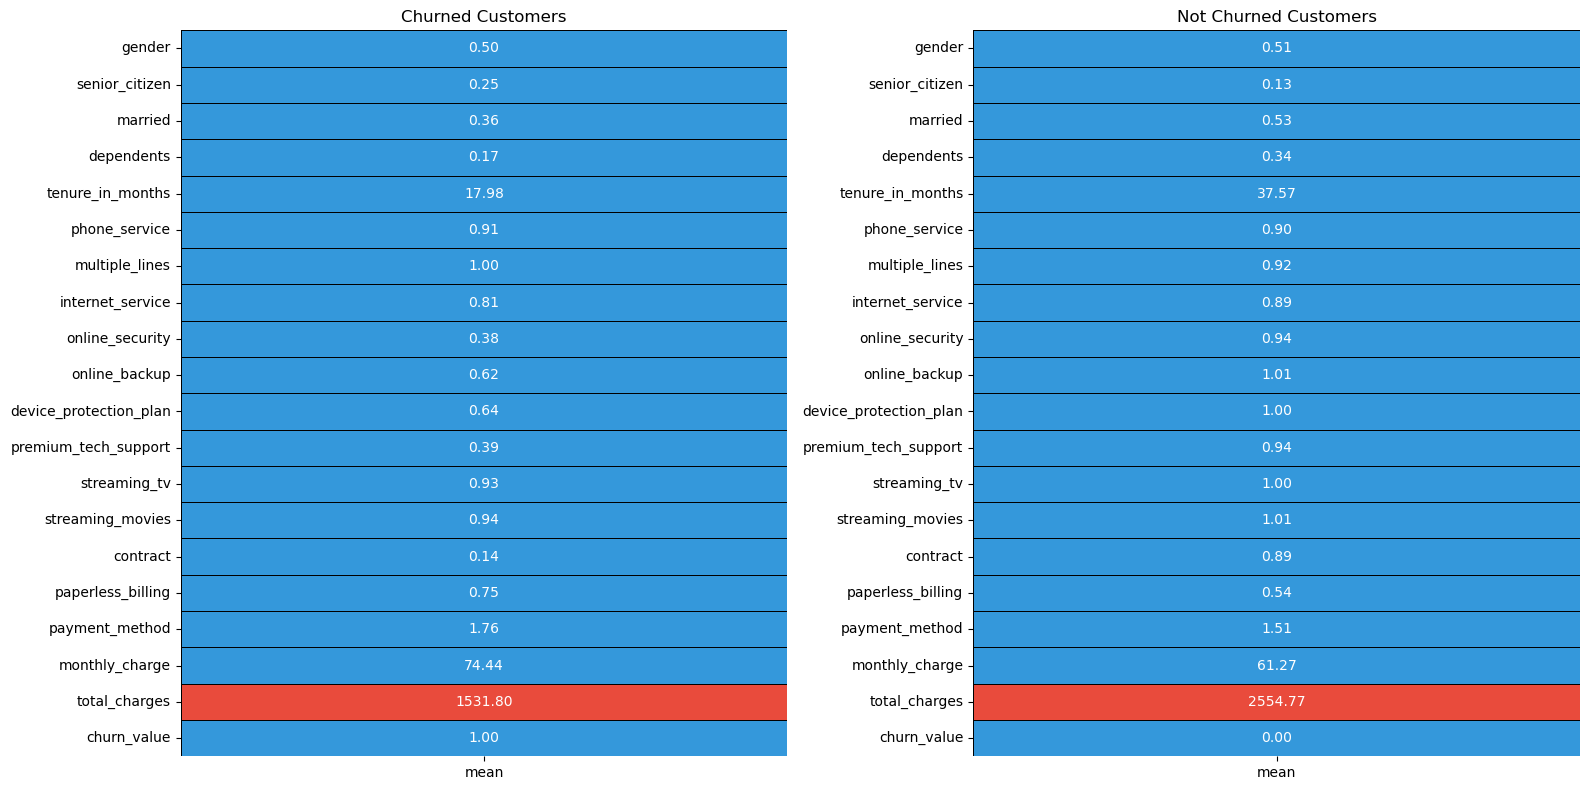

In [36]:
# Filtrons les données en fonction de la valeur de 'Churn'

colors = ['#3498db', '#E94B3C']
churn = base_copy[base_copy['churn_value'] == 1]
not_churn = base_copy[base_copy['churn_value'] == 0]

# statistiques descriptives 
churn_stats = churn.describe().T[['mean']]
not_churn_stats = not_churn.describe().T[['mean']]

# Création de subplots 
plt.figure(figsize=(16, 8))

# Heatmap pour churn
plt.subplot(1, 2, 1)
sns.heatmap(churn_stats, annot=True, cmap=colors, linewidths=0.4, linecolor='black', cbar=False, fmt='.2f')
plt.title('Churned Customers')

# Heatmap pour (not churned)
plt.subplot(1, 2, 2)
sns.heatmap(not_churn_stats, annot=True, cmap=colors, linewidths=0.4, linecolor='black', cbar=False, fmt='.2f')
plt.title('Not Churned Customers')

# Disposition
plt.tight_layout()
plt.show()


On constate que Les clients qui resilie on une charge moyenne de 1531,80 et les clients qui ne resilie pas on une charge moyenne de 2555,34  

### Catégorisons les données par Type

In [37]:
data = base_copy.copy()
data = data.drop('customer_id',axis = 1)


col = list(data.columns)
categorical_features = []
numerical_features = []
for i in col:
    if len(data[i].unique()) > 6:
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print('Categorical Features :',*categorical_features)
print('==========================================================================================================================')
print('Numerical Features :',*numerical_features)

Categorical Features : gender senior_citizen married dependents phone_service multiple_lines internet_service online_security online_backup device_protection_plan premium_tech_support streaming_tv streaming_movies contract paperless_billing payment_method churn_value
Numerical Features : tenure_in_months monthly_charge total_charges


### Visualisation

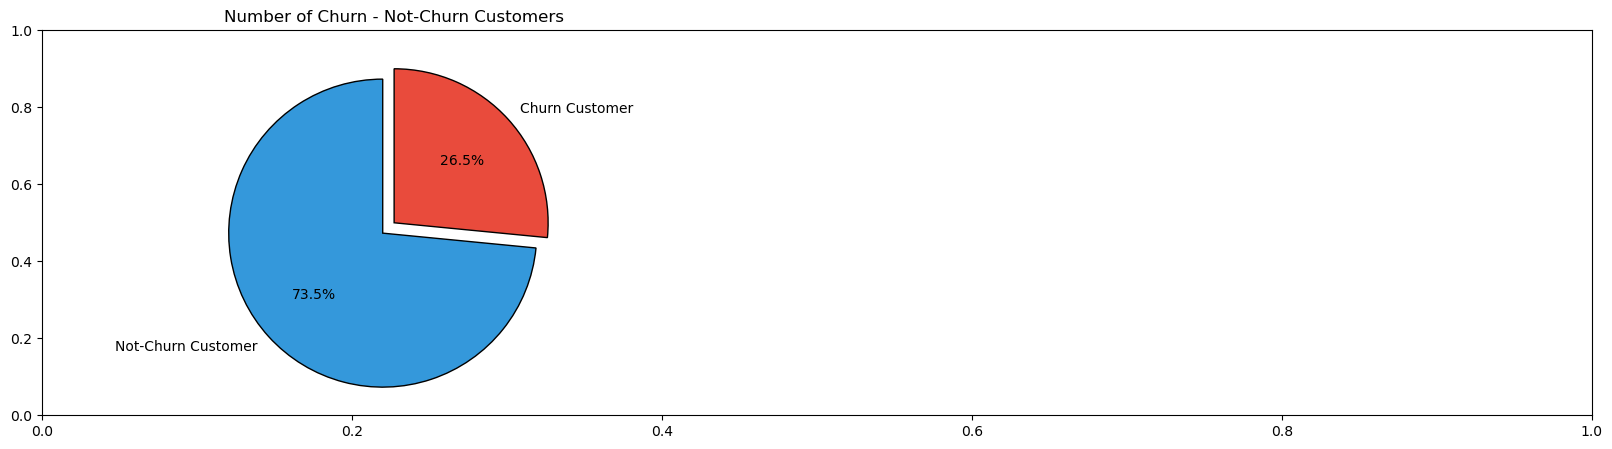

In [63]:
# répartition des clients 
l = list(data['churn_value'].value_counts())
circle = [l[0] / sum(l) * 100,l[1] / sum(l) * 100]

# fréquence de résiliation
fig = plt.subplots(nrows = 1,ncols = 1,figsize = (20,5))
plt.subplot(1,2,1)
plt.pie(circle,labels = ['Not-Churn Customer','Churn Customer'],autopct = '%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Churn - Not-Churn %');


plt.title('Number of Churn - Not-Churn Customers');
plt.show()

In [64]:
# variables par groupes 

l1 = ['gender','senior_citizen','married','dependents'] 
l2 = ['phone_service','multiple_lines','internet_service','online_security','streaming_movies','streaming_tv','online_backup','device_protection_plan','premium_tech_support'] 
l3 = ['contract','paperless_billing','payment_method'] 

In [65]:
# Calcul des pourcentages des clients ayant résilié leur abonnement

df1 = data.copy()
# Pour les clients ayant résilié leur abonnement
gender = df1[df1['churn_value'] == 1]['gender'].value_counts()
gender = [gender[0] / sum(gender) * 100, gender[1] / sum(gender) * 100]

# Pour senior des clients ayant résilié leur abonnement
seniorcitizen = df1[df1['churn_value'] == 1]['senior_citizen'].value_counts()
seniorcitizen = [seniorcitizen[0] / sum(seniorcitizen) * 100,seniorcitizen[1] / sum(seniorcitizen) * 100] 

# pour le statut de partenaire des clients ayant résilié leur abonnement
partner = df1[df1['churn_value'] == 1]['married'].value_counts()
partner = [partner[0] / sum(partner) * 100,partner[1] / sum(partner) * 100] 

# Calcul des pourcentages pour le nombre de personnes à charge des clients ayant résilié leur abonnement
dependents = df1[df1['churn_value'] == 1]['dependents'].value_counts()
dependents = [dependents[0] / sum(dependents) * 100,dependents[1] / sum(dependents) * 100] 


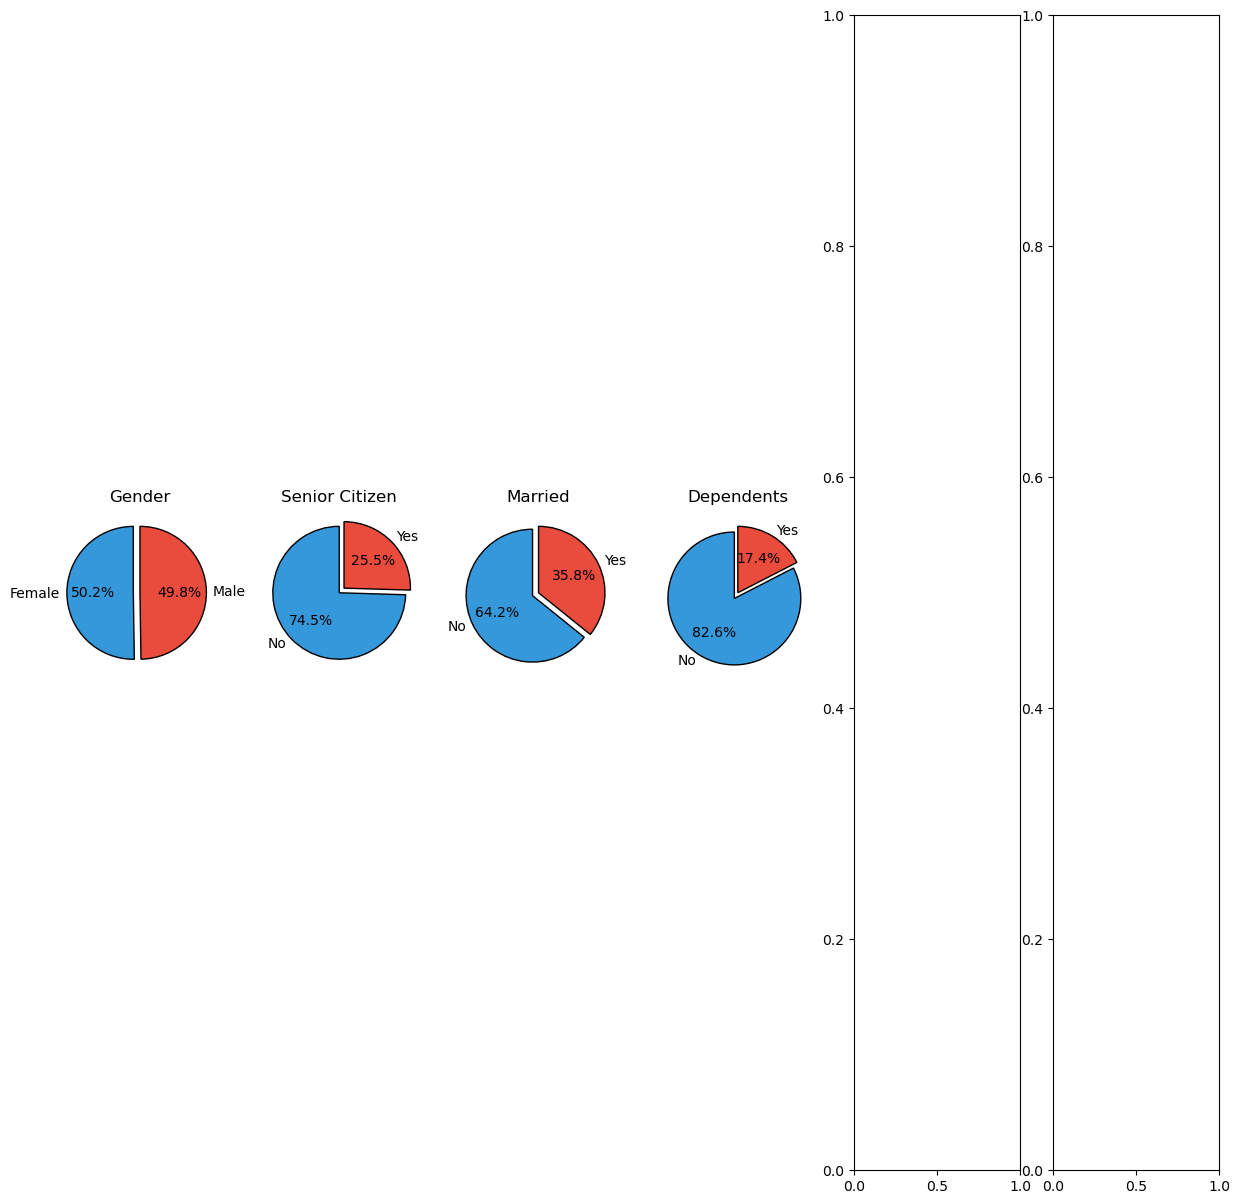

In [66]:
# Répartition des Clients Ayant Résilié leur Abonnement 

ax,fig = plt.subplots(nrows = 1,ncols = 6,figsize = (15,15))

plt.subplot(1,6,1)
plt.pie(gender,labels = ['Female','Male'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Gender');

plt.subplot(1,6,2)
plt.pie(seniorcitizen,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Senior Citizen');

plt.subplot(1,6,3)
plt.pie(partner,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Married');

plt.subplot(1,6,4)
plt.pie(dependents,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Dependents');

Les clients ayant résilié leur abonnement sont répartis de manière presque égale entre hommes et femmes, montrant que le genre n'influence pas significativement la résiliation. La majorité ne sont pas des citoyens âgés (74,5%), suggérant que les jeunes adultes sont plus enclins à annuler. De plus, une large proportion de ces clients sont non mariés (64,2%) et n'ont pas de personnes à charge (82,6%), indiquant qu'ils ont moins d'engagements personnels ce qui suggèrent que les résiliations sont plus fréquentes parmi les clients jeunes, célibataires, et sans responsabilités familiales.

In [67]:
# Répartition des Services Utilisés par les Clients Ayant Résilié leur Abonnement

phoneservice = df1[df1['churn_value'] == 1]['phone_service'].value_counts()
phoneservice = [phoneservice[0] / sum(phoneservice) * 100, phoneservice[1] / sum(phoneservice) * 100] 

multiplelines = df1[df1['churn_value'] == 1]['multiple_lines'].value_counts()
multiplelines = [multiplelines[0] / sum(multiplelines) * 100,multiplelines[1] / sum(multiplelines) * 100]  

internetservice = df1[df1['churn_value'] == 1]['internet_service'].value_counts()
internetservice = [internetservice[0] / sum(internetservice) * 100,internetservice[1] / sum(internetservice) * 100] 

streamingtv = df1[df1['churn_value'] == 1]['streaming_tv'].value_counts()
streamingtv = [streamingtv[0] / sum(streamingtv) * 100,streamingtv[1] / sum(streamingtv) * 100] 

streamingmovies = df1[df1['churn_value'] == 1]['streaming_movies'].value_counts()
streamingmovies = [streamingmovies[0] / sum(streamingmovies) * 100,streamingmovies[1] / sum(streamingmovies) * 100]  

onlinesecurity = df1[df1['churn_value'] == 1]['online_security'].value_counts()
onlinesecurity = [onlinesecurity[0] / sum(onlinesecurity) * 100,onlinesecurity[1] / sum(onlinesecurity) * 100]  

onlinebackup = df1[df1['churn_value'] == 1]['online_backup'].value_counts()
onlinebackup = [onlinebackup[0] / sum(onlinebackup) * 100,onlinebackup[1] / sum(onlinebackup) * 100] 

deviceprotection = df1[df1['churn_value'] == 1]['device_protection_plan'].value_counts()
deviceprotection = [deviceprotection[0] / sum(deviceprotection) * 100,deviceprotection[1] / sum(deviceprotection) * 100]  

techsupport = df1[df1['churn_value'] == 1]['premium_tech_support'].value_counts()
techsupport = [techsupport[0] / sum(techsupport) * 100,techsupport[1] / sum(techsupport) * 100] 

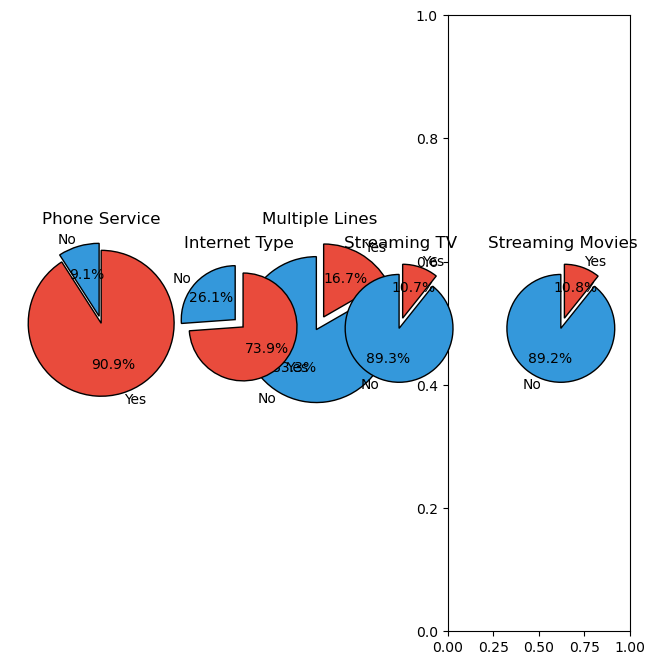

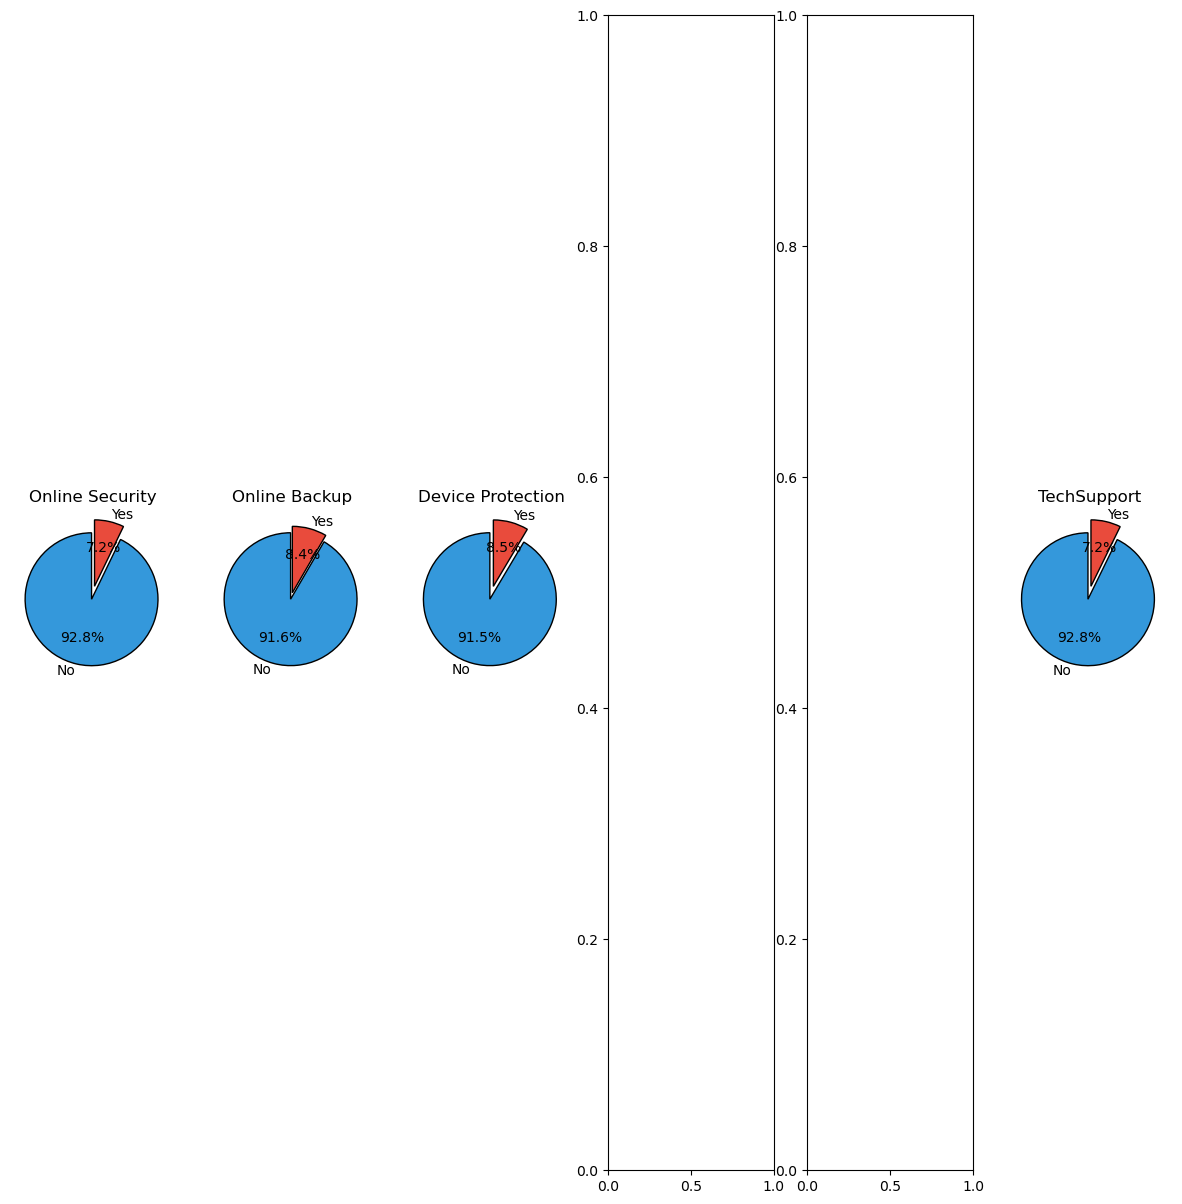

In [68]:
# visualition

ax,fig = plt.subplots(nrows = 1,ncols = 3,figsize = (8,8))

plt.subplot(1,3,1)
plt.pie(phoneservice,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Phone Service');

plt.subplot(1,3,2)
plt.pie(multiplelines,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Multiple Lines');

plt.subplot(1,4,2)
plt.pie(internetservice,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Internet Type');

plt.subplot(1,4,3)
plt.pie(streamingtv,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Streaming TV');

plt.subplot(1,4,4)
plt.pie(streamingmovies,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Streaming Movies');

ax,fig = plt.subplots(nrows = 1,ncols = 6,figsize = (15,15))

plt.subplot(1,6,1)
plt.pie(onlinesecurity,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Online Security');

plt.subplot(1,6,2)
plt.pie(onlinebackup,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Online Backup');

plt.subplot(1,6,3)
plt.pie(deviceprotection,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Device Protection');

plt.subplot(1,6,6)
plt.pie(techsupport,labels = ['No','Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('TechSupport');

In [69]:
# Répartition des Types de Contrat

contract = df1[df1['churn_value'] == 1]['contract'].value_counts()
contract = [contract[0] / sum(contract) * 100, contract[1] / sum(contract) * 100, contract[2] / sum(contract) * 100] 

paperlessbilling = df1[df1['churn_value'] == 1]['paperless_billing'].value_counts()
paperlessbilling = [paperlessbilling[0] / sum(paperlessbilling) * 100,paperlessbilling[1] / sum(paperlessbilling) * 100] 

paymentmethod = df1[df1['churn_value'] == 1]['payment_method'].value_counts()
paymentmethod = [paymentmethod[0] / sum(paymentmethod) * 100, paymentmethod[1] / sum(paymentmethod) * 100,paymentmethod[2] / sum(paymentmethod) * 100]

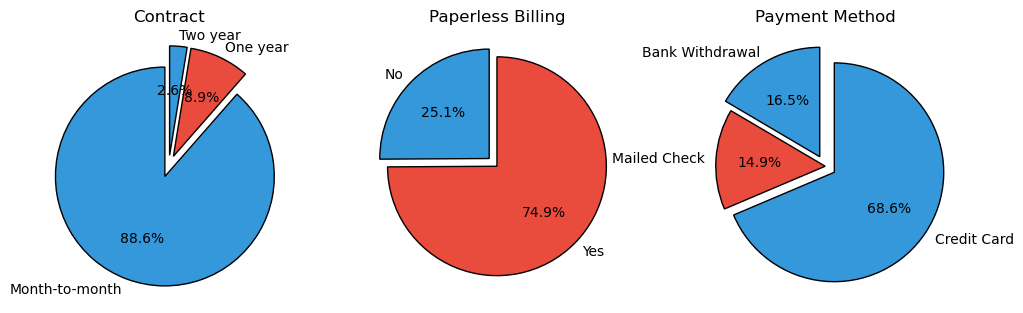

In [70]:
# Visualisation

ax,fig = plt.subplots(nrows = 1,ncols = 3,figsize = (12,12))

plt.subplot(1,3,1)
plt.pie(contract,labels = ['Month-to-month','One year','Two year'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0.1,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Contract');

plt.subplot(1,3,2)
plt.pie(paperlessbilling,labels = ['No', 'Yes'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Paperless Billing');

plt.subplot(1,3,3)
plt.pie(paymentmethod,labels = ['Bank Withdrawal','Mailed Check','Credit Card'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0,0.1),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
plt.title('Payment Method');

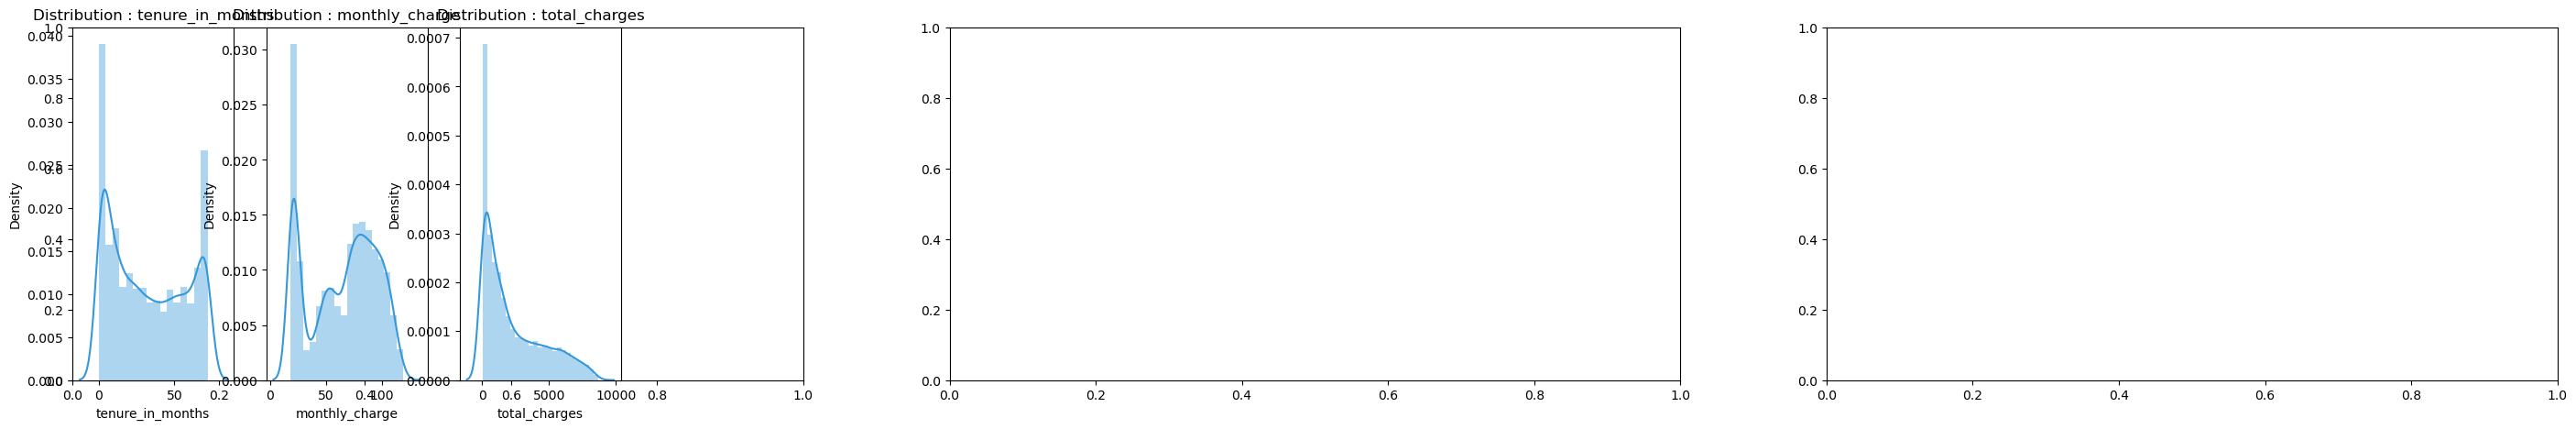

In [71]:
# Distribution des Variables Numériques

fig, ax = plt.subplots(nrows = 1,ncols = 3,figsize = (35,5))
for i in range(len(numerical_features)):
    plt.subplot(1,13,i+1)
    sns.distplot(df1[numerical_features[i]],color = colors[0])
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

#### Examinons l'ancienneté en mois en relation avec diverses variables

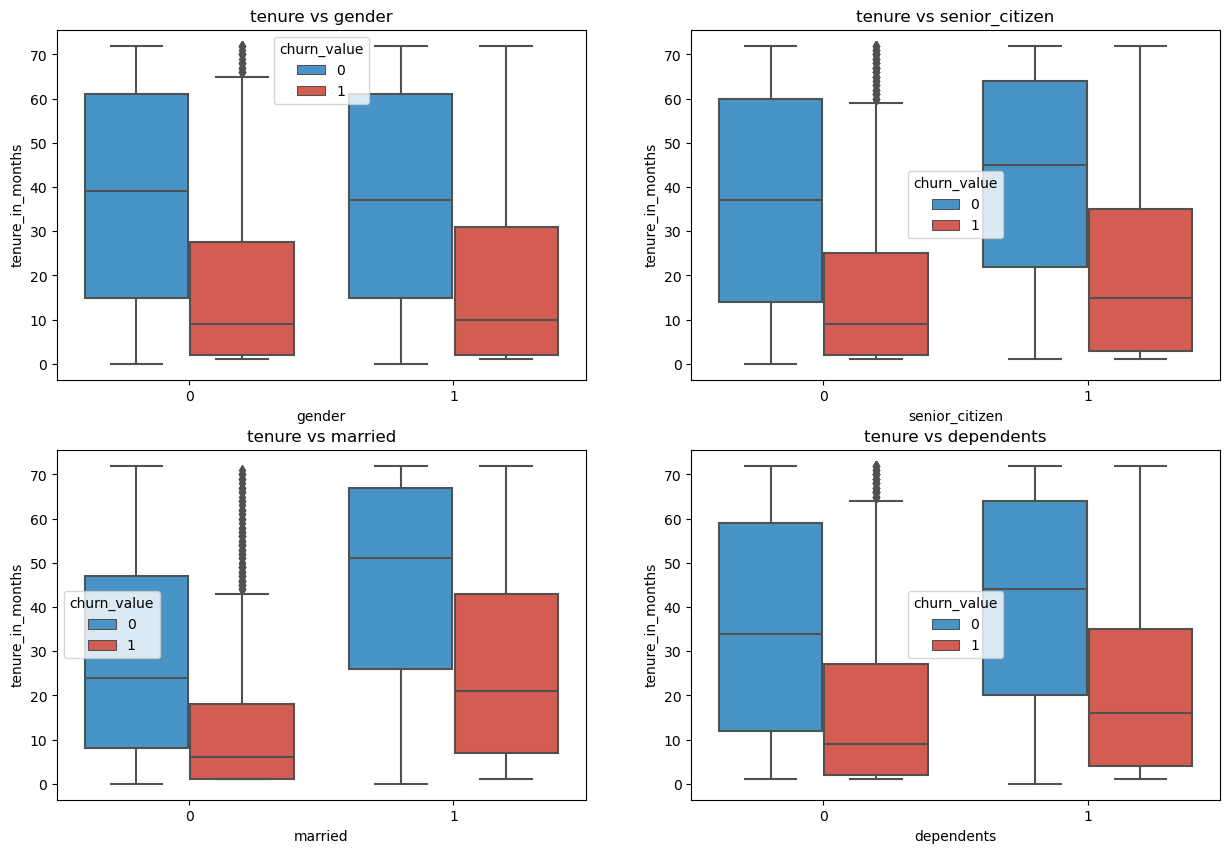

In [72]:
#  visualisation 

fig = plt.subplots(nrows = 2,ncols = 2,figsize = (15,10))
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = l1[i],y = 'tenure_in_months',data = df1,hue = 'churn_value',palette = colors);
    plt.title('tenure vs ' + l1[i]);

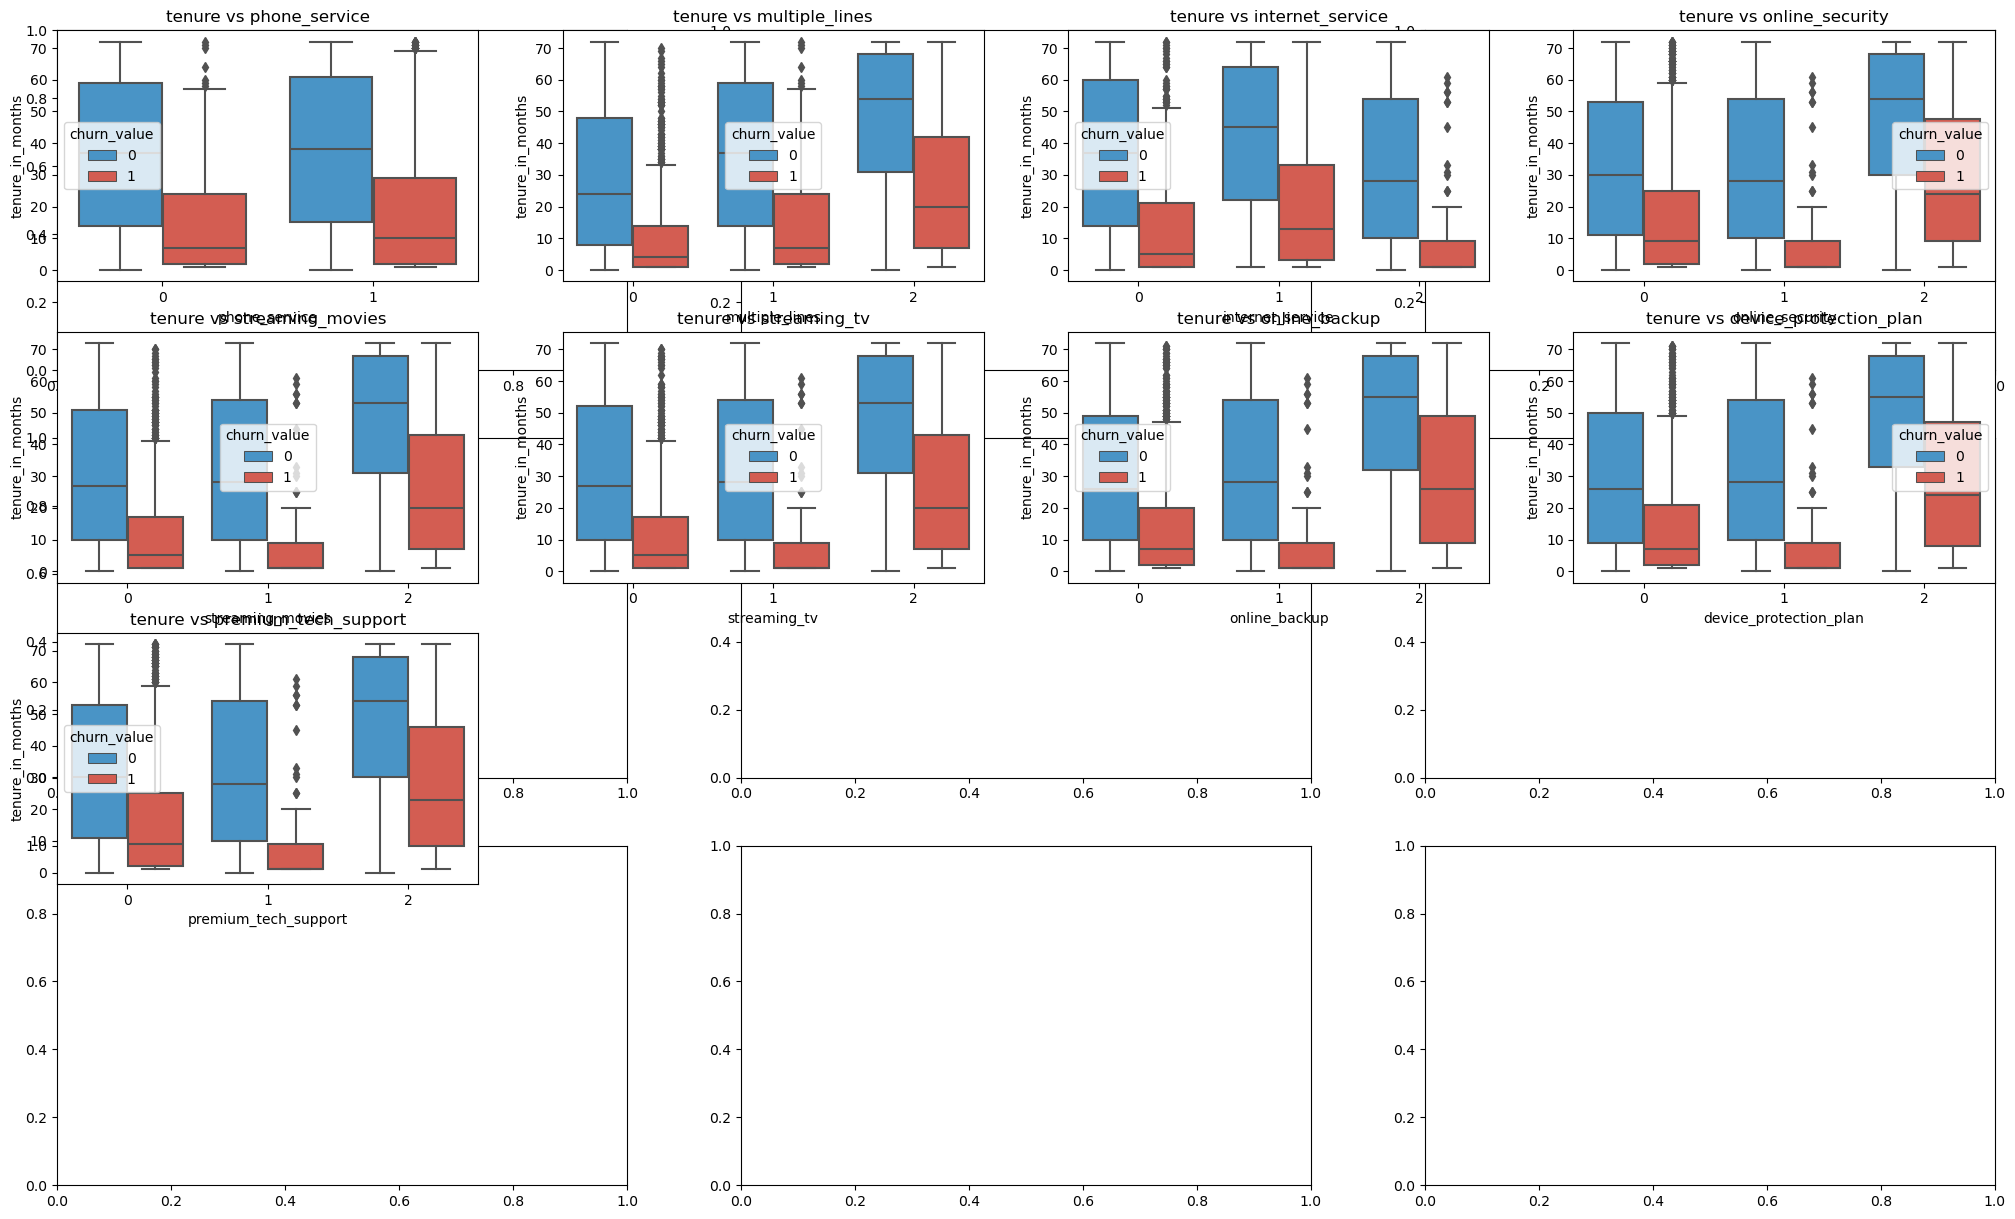

In [73]:
# Déterminons le nombre de graphiques en fonction de la longueur de l2

num_plots = min(len(l2), 12)

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(25, 15))

for i in range(num_plots):
    plt.subplot(4, 4, i + 1)
    ax = sns.boxplot(x=l2[i], y='tenure_in_months', data=df1, hue='churn_value', palette=colors)
    plt.title('tenure vs ' + l2[i])

plt.tight_layout()
plt.show()

#### Analyse de l'Ancienneté en Fonction des Variables Categorielles

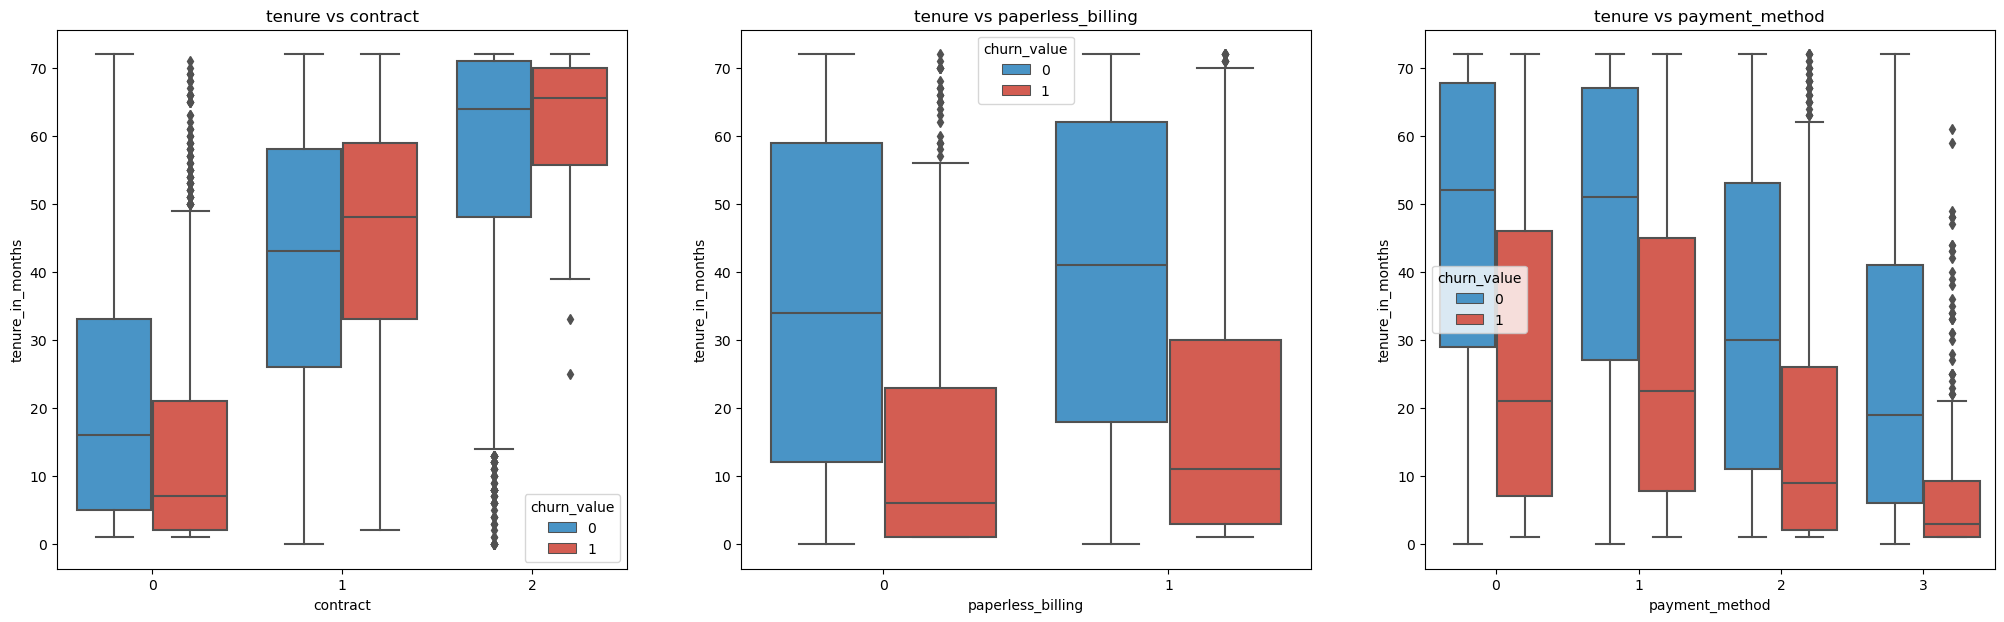

In [74]:
# Analyse 
fig = plt.subplots(nrows = 1,ncols = 3,figsize = (25,7))
for i in range(len(l3)):
    plt.subplot(1,3,i + 1)
    ax = sns.boxplot(x = l3[i],y = 'tenure_in_months',data = df1,hue = 'churn_value',palette = colors);
    plt.title('tenure vs ' + l3[i]);

 #### Analyse des Frais Mensuels en Fonction des Variables Categorielles

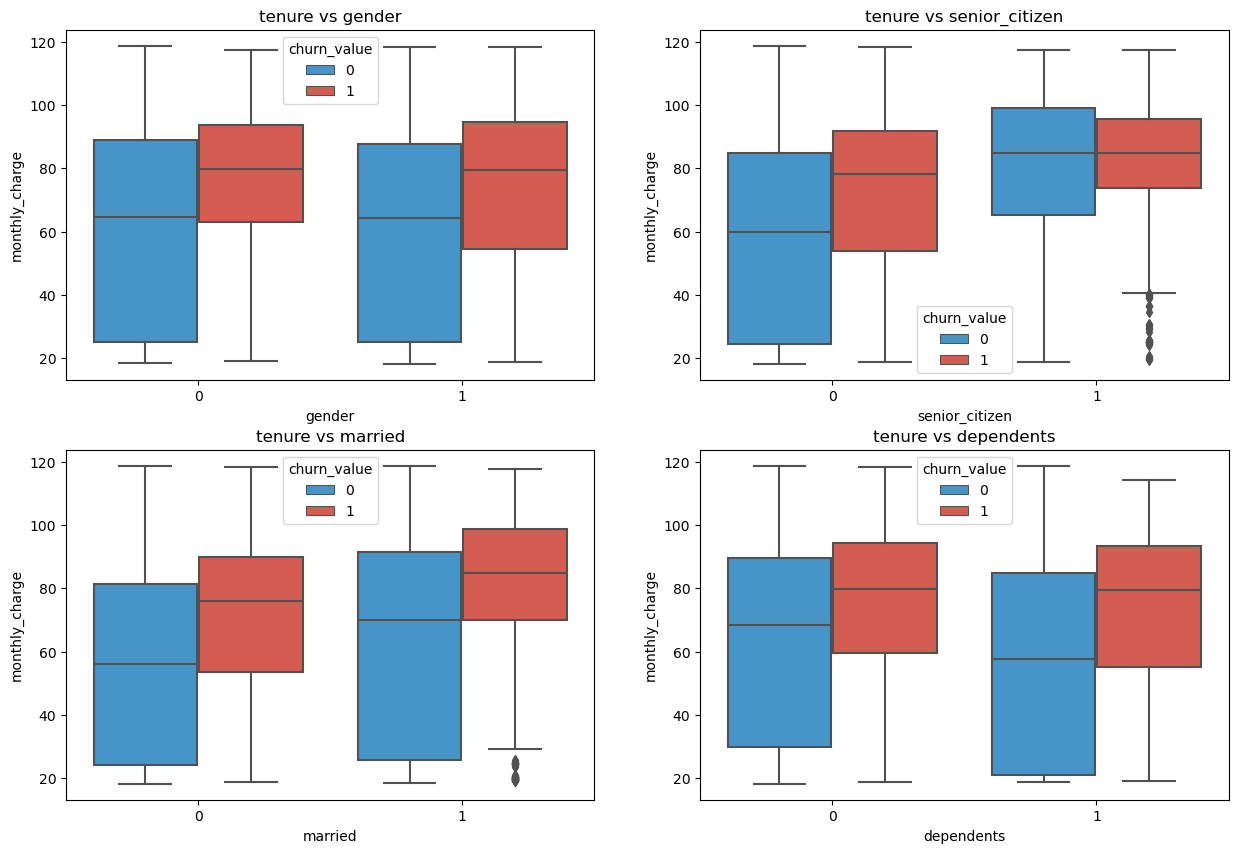

In [75]:
# Analyse 
fig = plt.subplots(nrows = 2,ncols = 2,figsize = (15,10))
for i in range(4):
    plt.subplot(2,2,i+1)
    ax = sns.boxplot(x = l1[i],y = 'monthly_charge',data = df1,hue = 'churn_value',palette = colors);
    plt.title('tenure vs ' + l1[i]);

#### Corrélation avec Matrix de Pearson 

In [76]:
df1.head()

,gender,senior_citizen,married,dependents,tenure_in_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charge,total_charges,churn_value
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [77]:
df1.describe()

,gender,senior_citizen,married,dependents,tenure_in_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charge,total_charges,churn_value
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.50,0.16,0.48,0.30,32.37,0.90,0.94,0.87,0.79,0.91,0.90,0.80,0.99,0.99,0.69,0.59,1.57,64.76,2283.30,0.27
std,0.50,0.37,0.50,0.46,24.56,0.30,0.95,0.74,0.86,0.88,0.88,0.86,0.89,0.89,0.83,0.49,1.07,30.09,2265.00,0.44
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.25,18.80,0.00
25%,0.00,0.00,0.00,0.00,9.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,35.50,402.23,0.00
50%,1.00,0.00,0.00,0.00,29.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,2.00,70.35,1400.55,0.00
75%,1.00,0.00,1.00,1.00,55.00,1.00,2.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,1.00,2.00,89.85,3786.60,1.00
max,1.00,1.00,1.00,1.00,72.00,1.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,3.00,118.75,8684.80,1.00


In [78]:
# Normalisation et Standardisation des Variables de Durée

from sklearn.preprocessing import MinMaxScaler,StandardScaler
mms = MinMaxScaler() 
ss = StandardScaler() 

df1['tenure_in_months'] = mms.fit_transform(df1[['tenure_in_months']])
df1['total_charges'] = mms.fit_transform(df1[['total_charges']])
df1['monthly_charge'] = mms.fit_transform(df1[['monthly_charge']])
df1.head()

,gender,senior_citizen,married,dependents,tenure_in_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charge,total_charges,churn_value
0,0,0,1,0,0.01,0,1,0,0,2,0,0,0,0,0,1,2,0.12,0.00,0
1,1,0,0,0,0.47,1,0,0,2,0,2,0,0,0,1,0,3,0.39,0.22,0
2,1,0,0,0,0.03,1,0,0,2,2,0,0,0,0,0,1,3,0.35,0.01,1
3,1,0,0,0,0.62,0,1,0,2,0,2,2,0,0,1,0,0,0.24,0.21,0
4,0,0,0,0,0.03,1,0,1,0,0,0,0,0,0,0,1,2,0.52,0.02,1


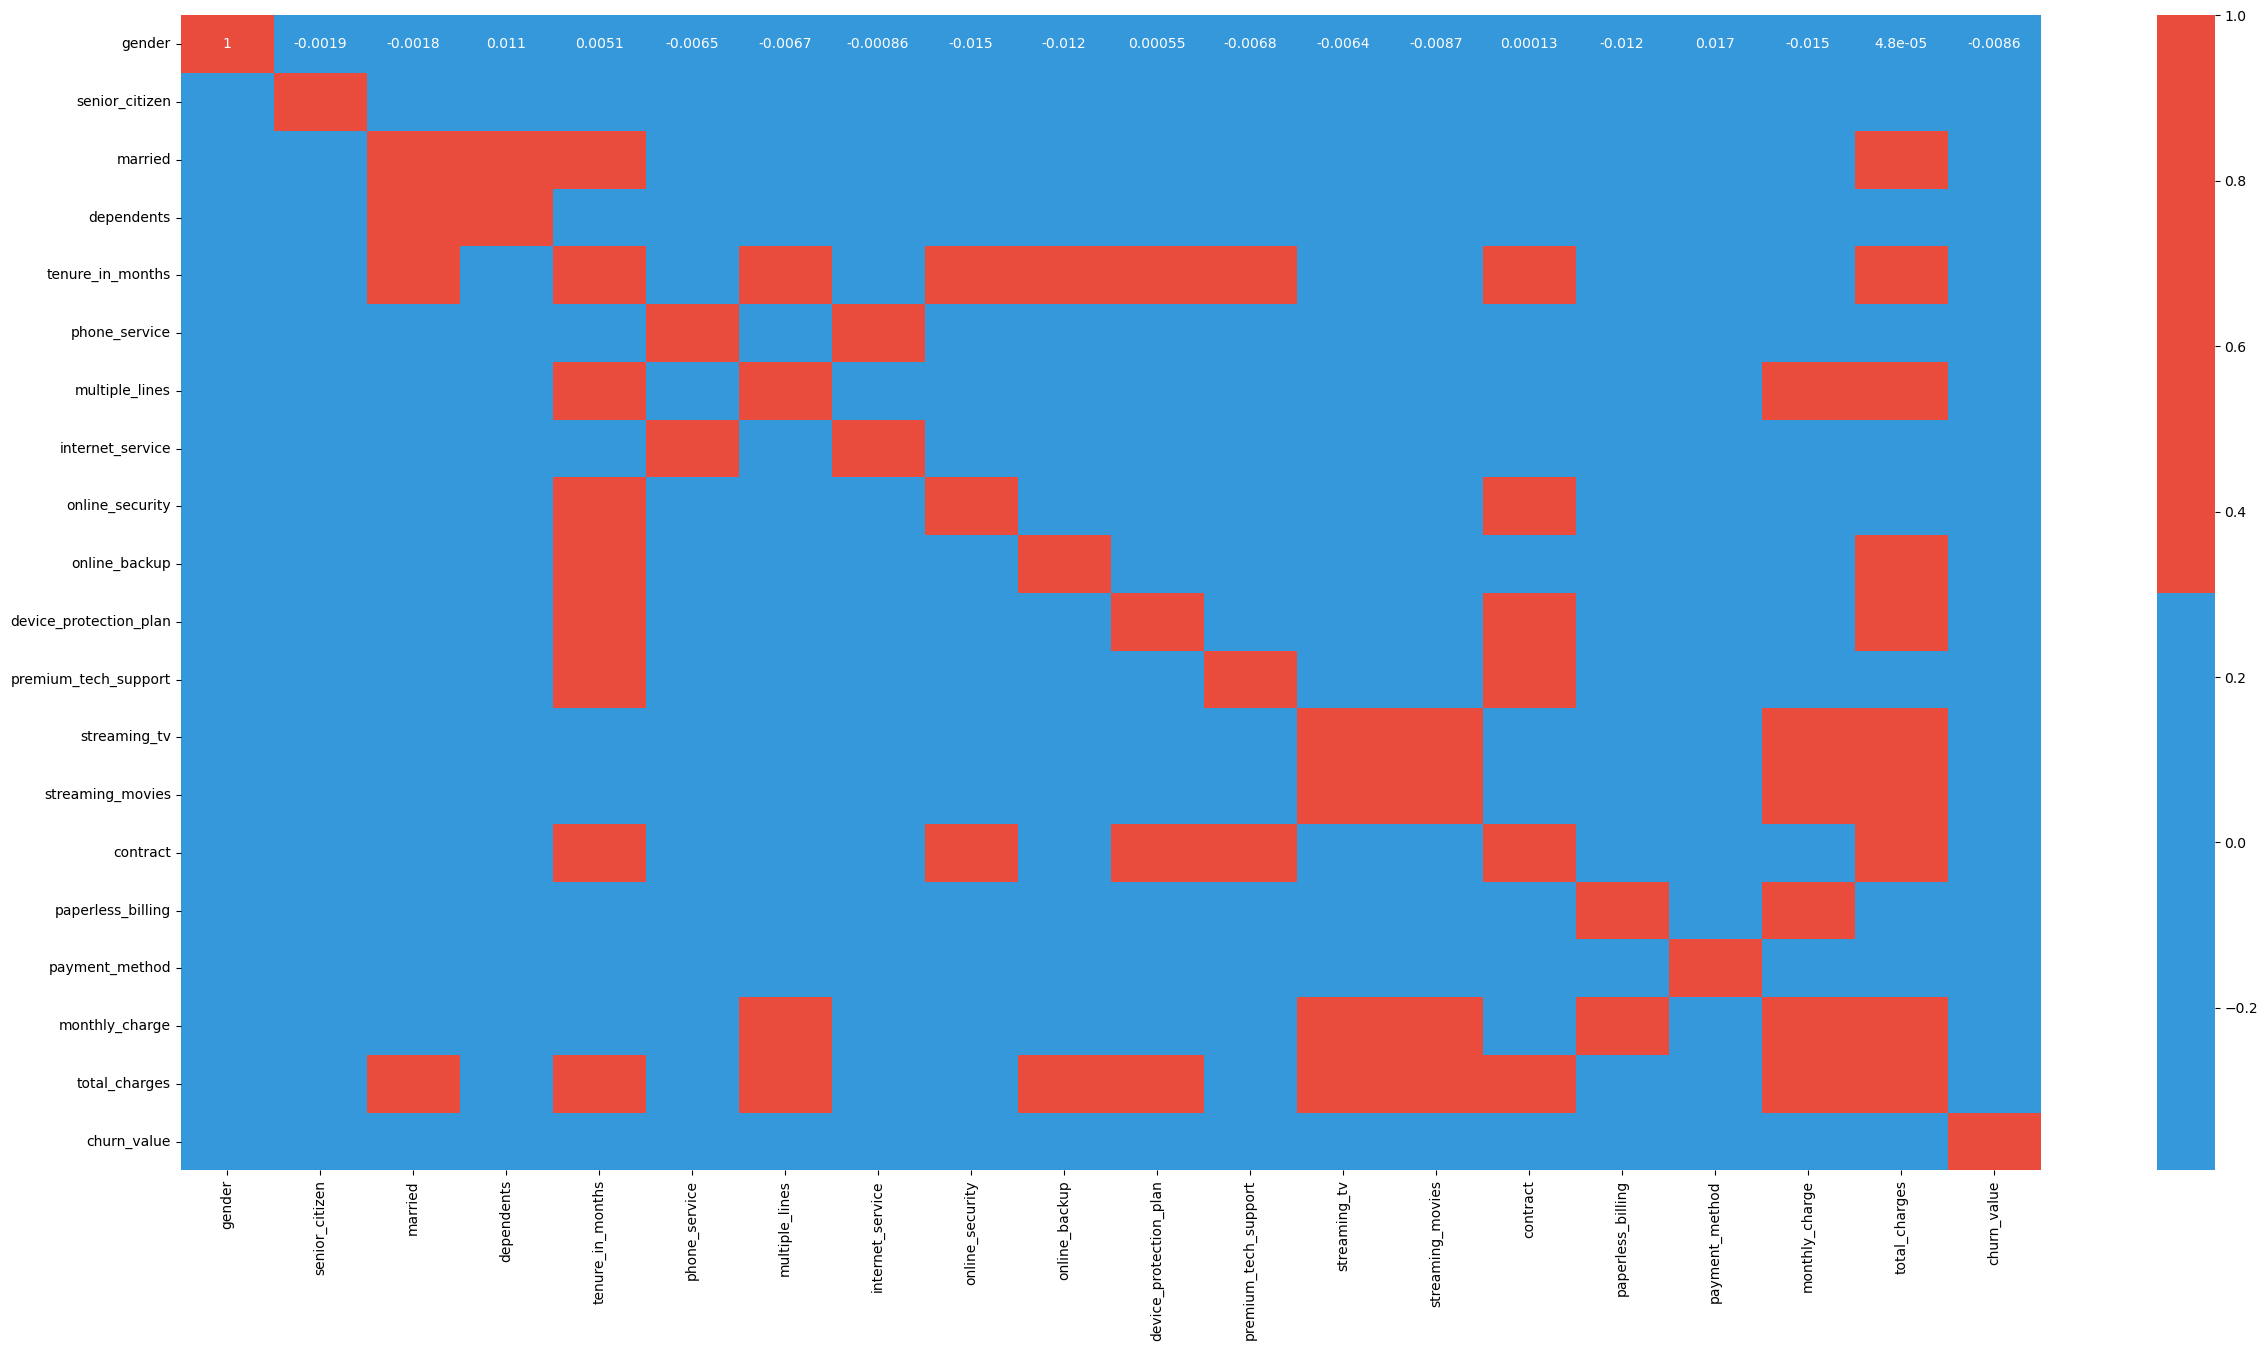

In [79]:
# Matrix de Pearson 

plt.figure(figsize = (30,15))
sns.heatmap(df1.corr(),cmap = colors,annot = True);

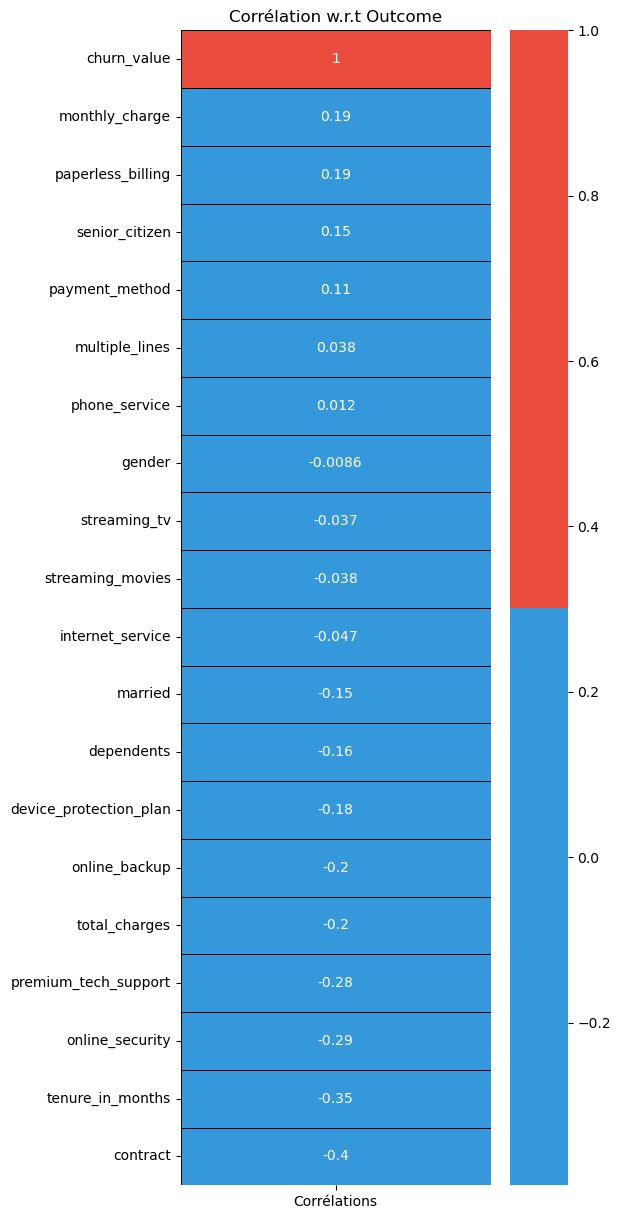

In [80]:
# visualisons les corrélations entre la variable cible

corr = df1.corrwith(df1['churn_value']).sort_values(ascending = False).to_frame()
corr.columns = ['Corrélations']
plt.subplots(figsize = (5,15))
sns.heatmap(corr,annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black');
plt.title('Corrélation w.r.t Outcome');

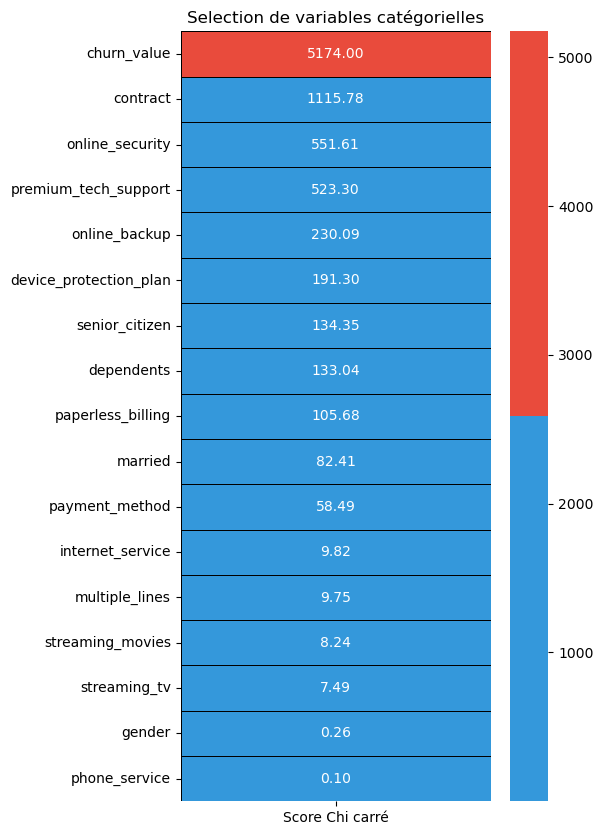

In [81]:
# Sélection des Variables Catégorielles 

features = df1.loc[:,categorical_features]
target = df1.loc[:,'churn_value']

best_features = SelectKBest(score_func = chi2,k = 'all')
fit = best_features.fit(features,target)

featureScores = pd.DataFrame(data = fit.scores_,index = list(features.columns),columns = ['Score Chi carré']) 

plt.subplots(figsize = (5,10))
sns.heatmap(featureScores.sort_values(ascending = False,by = 'Score Chi carré'),annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black',fmt = '.2f');
plt.title('Selection de variables catégorielles');

In [82]:
df2 = df1.copy(deep = True)
df2.head()

,gender,senior_citizen,married,dependents,tenure_in_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charge,total_charges,churn_value
0,0,0,1,0,0.01,0,1,0,0,2,0,0,0,0,0,1,2,0.12,0.00,0
1,1,0,0,0,0.47,1,0,0,2,0,2,0,0,0,1,0,3,0.39,0.22,0
2,1,0,0,0,0.03,1,0,0,2,2,0,0,0,0,0,1,3,0.35,0.01,1
3,1,0,0,0,0.62,0,1,0,2,0,2,2,0,0,1,0,0,0.24,0.21,0
4,0,0,0,0,0.03,1,0,1,0,0,0,0,0,0,0,1,2,0.52,0.02,1


In [83]:
# Supprimons des Colonnes

df2.drop(columns = ['phone_service', 'gender','multiple_lines','streaming_tv','payment_method', 'married',
                    'streaming_movies','device_protection_plan','online_backup'],inplace = True)
df2.head()

,senior_citizen,dependents,tenure_in_months,internet_service,online_security,premium_tech_support,contract,paperless_billing,monthly_charge,total_charges,churn_value
0,0,0,0.01,0,0,0,0,1,0.12,0.00,0
1,0,0,0.47,0,2,0,1,0,0.39,0.22,0
2,0,0,0.03,0,2,0,0,1,0.35,0.01,1
3,0,0,0.62,0,2,2,1,0,0.24,0.21,0
4,0,0,0.03,1,0,0,0,1,0.52,0.02,1


In [84]:
df3 = df1.copy(deep = True)
df3.head()

,gender,senior_citizen,married,dependents,tenure_in_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charge,total_charges,churn_value
0,0,0,1,0,0.01,0,1,0,0,2,0,0,0,0,0,1,2,0.12,0.00,0
1,1,0,0,0,0.47,1,0,0,2,0,2,0,0,0,1,0,3,0.39,0.22,0
2,1,0,0,0,0.03,1,0,0,2,2,0,0,0,0,0,1,3,0.35,0.01,1
3,1,0,0,0,0.62,0,1,0,2,0,2,2,0,0,1,0,0,0.24,0.21,0
4,0,0,0,0,0.03,1,0,1,0,0,0,0,0,0,0,1,2,0.52,0.02,1


In [85]:
# Suppression de la Colonne 'churn_value' du DataFrame
df3.drop('churn_value',axis=1, inplace=True)

### Modélisation

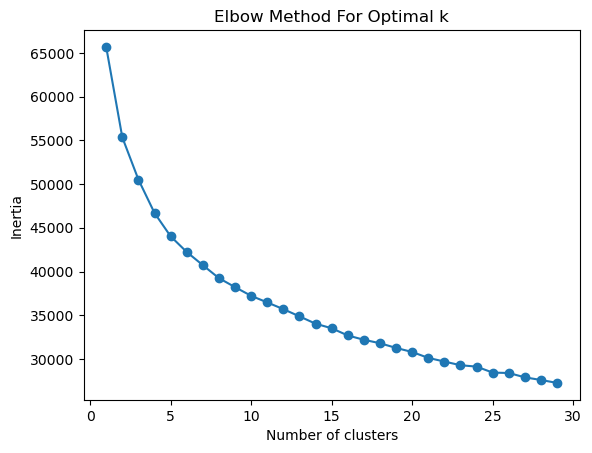

In [87]:
# Nombre Optimal de Clusters
imputer = SimpleImputer(strategy='mean')
df3_imputed = imputer.fit_transform(df3)

n_clusters = 30
cost = []

for i in range(1, n_clusters):
    kmean = KMeans(n_clusters=i)
    kmean.fit(df3_imputed)
    cost.append(kmean.inertia_)

import matplotlib.pyplot as plt

plt.plot(range(1, n_clusters), cost, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

la méthode du coude de elbow nous montre que le nombre de cluster optimal est de K=5.

In [88]:
# Application de KMeans
imputer = SimpleImputer(strategy='mean')
df3_imputed = imputer.fit_transform(df3)

kmean = KMeans(5)
kmean.fit(df3_imputed)
labels = kmean.labels_


print(labels)

[0 4 0 ... 0 0 1]


In [89]:
# Attribution des Clusters aux Données Imputées

clusters=pd.concat([df3, pd.DataFrame({'cluster':labels})], axis=1)
clusters.head()

,gender,senior_citizen,married,dependents,tenure_in_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charge,total_charges,cluster
0,0,0,1,0,0.01,0,1,0,0,2,0,0,0,0,0,1,2,0.12,0.00,0
1,1,0,0,0,0.47,1,0,0,2,0,2,0,0,0,1,0,3,0.39,0.22,4
2,1,0,0,0,0.03,1,0,0,2,2,0,0,0,0,0,1,3,0.35,0.01,0
3,1,0,0,0,0.62,0,1,0,2,0,2,2,0,0,1,0,0,0.24,0.21,3
4,0,0,0,0,0.03,1,0,1,0,0,0,0,0,0,0,1,2,0.52,0.02,0


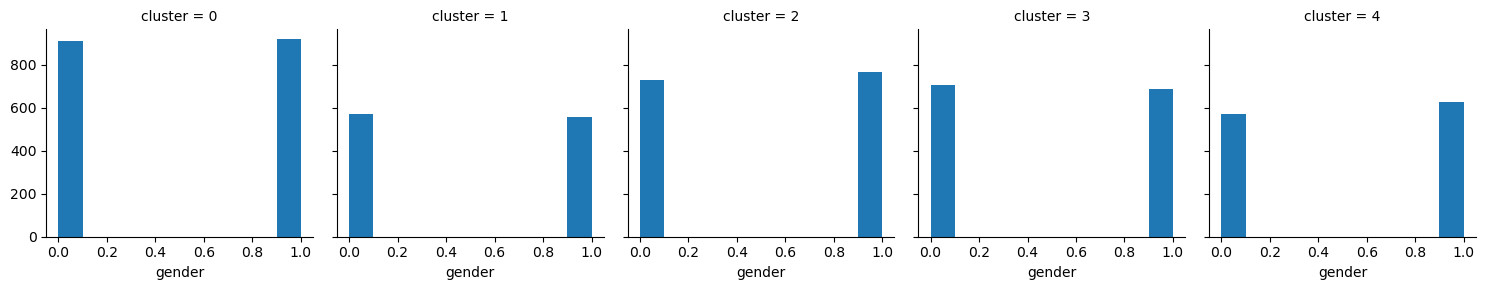

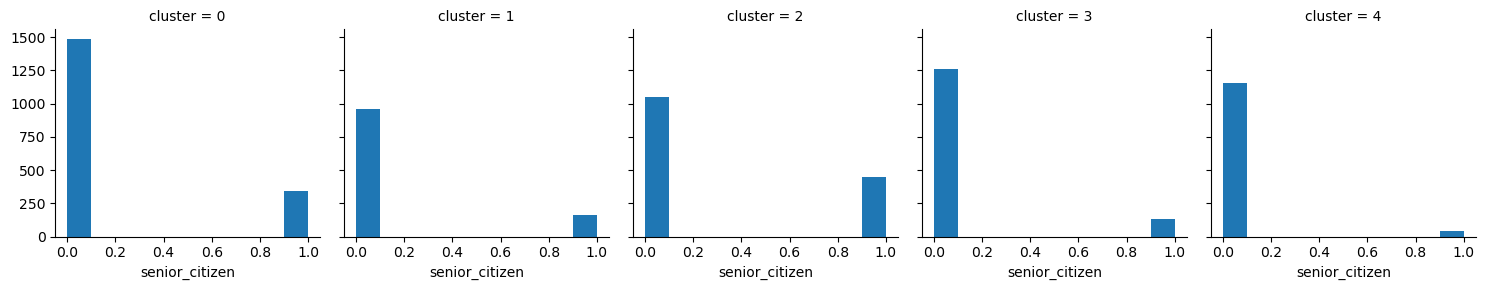

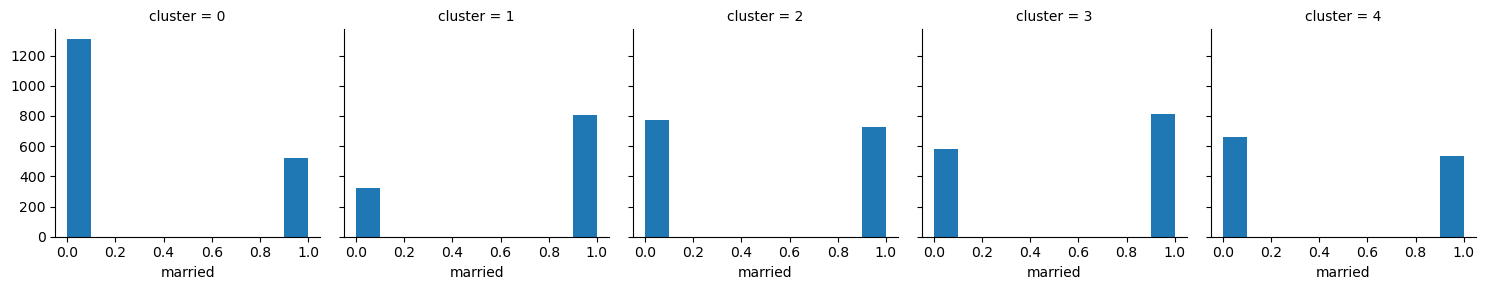

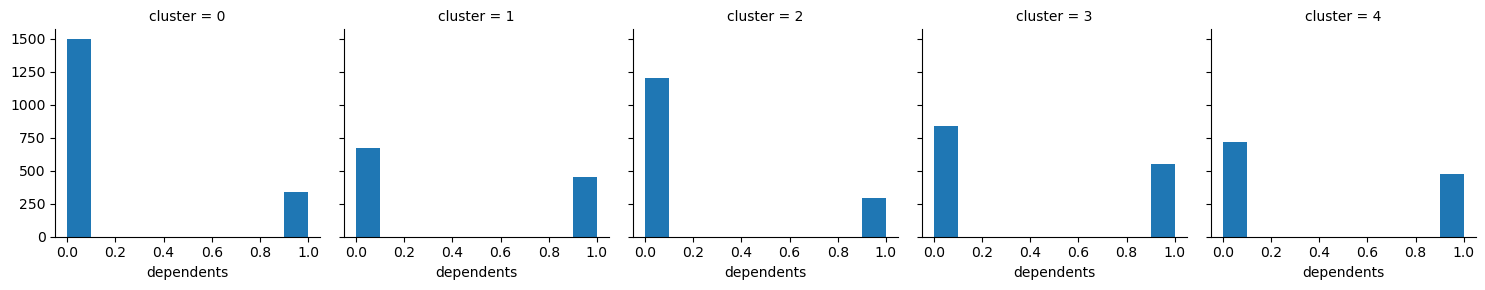

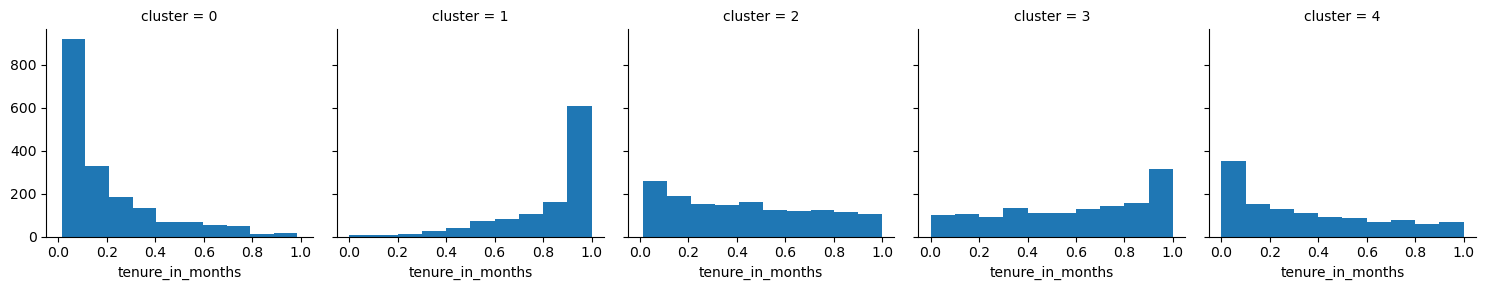

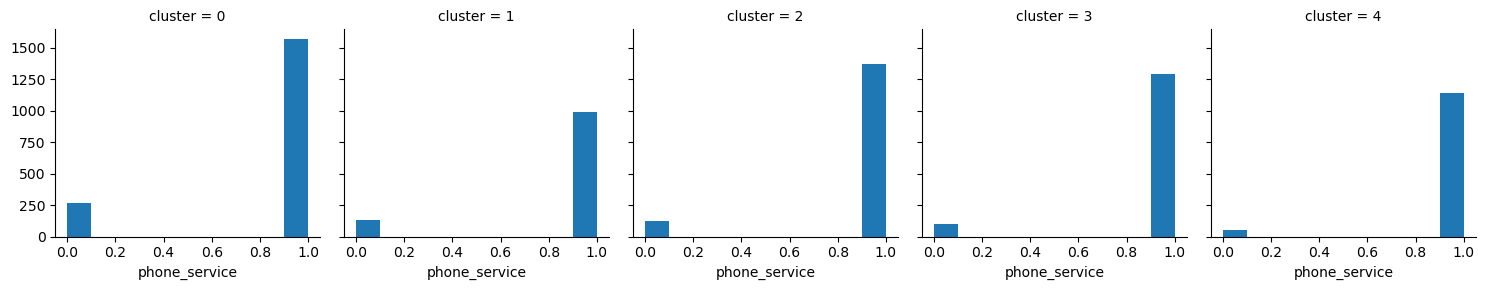

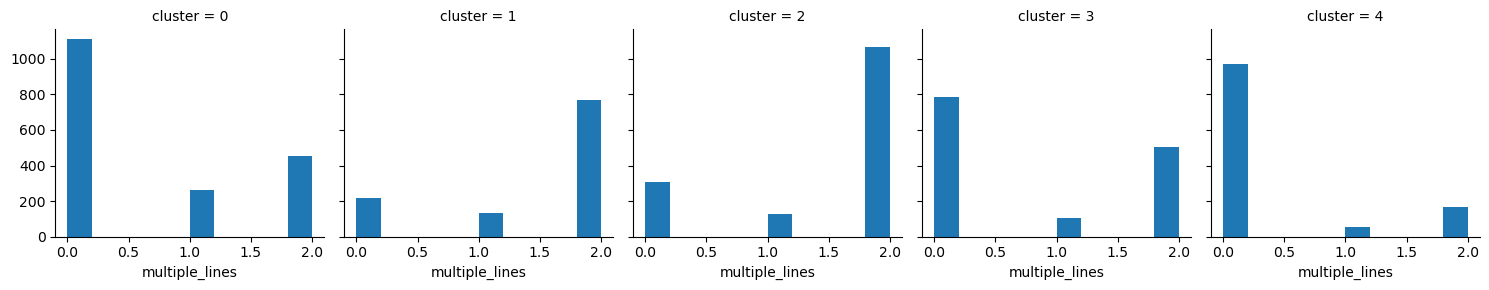

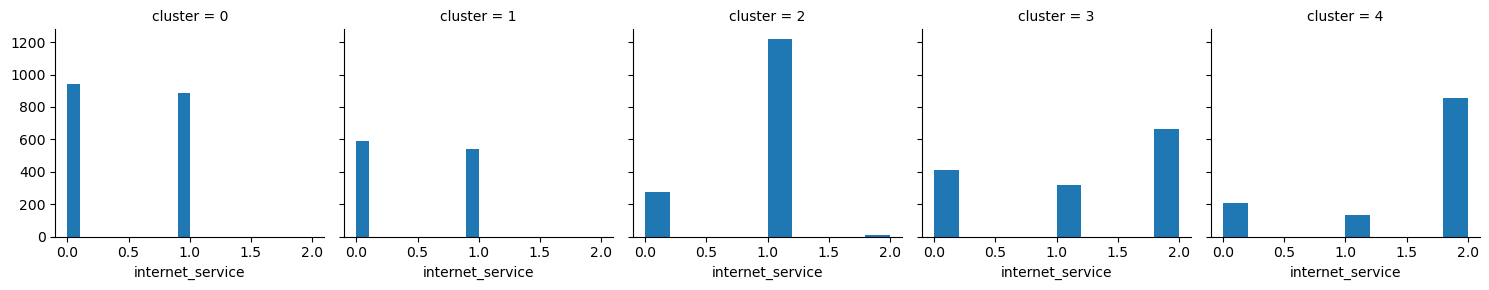

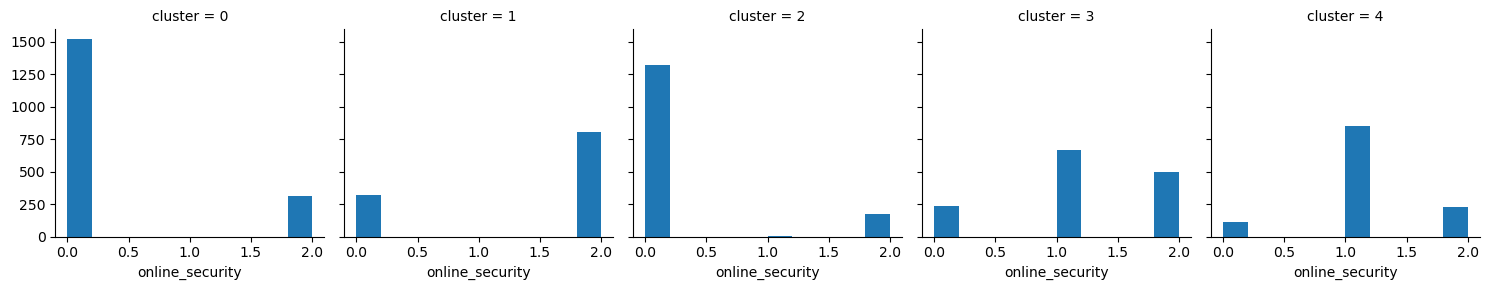

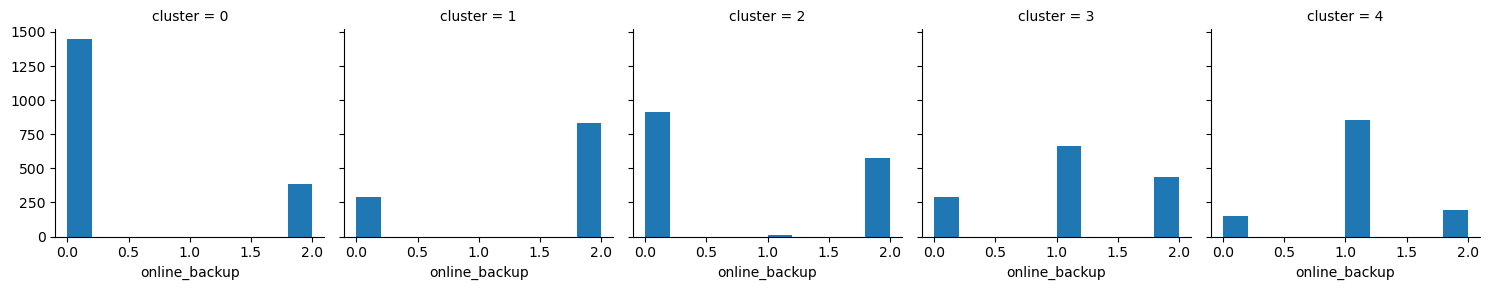

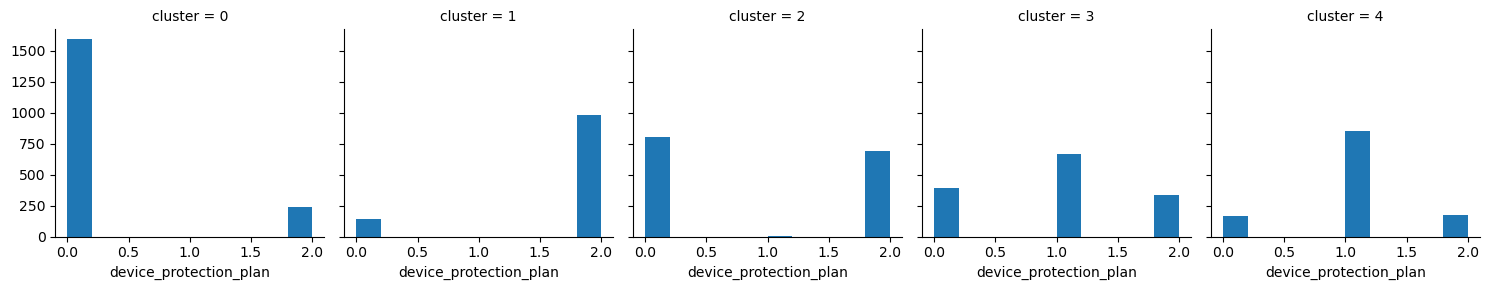

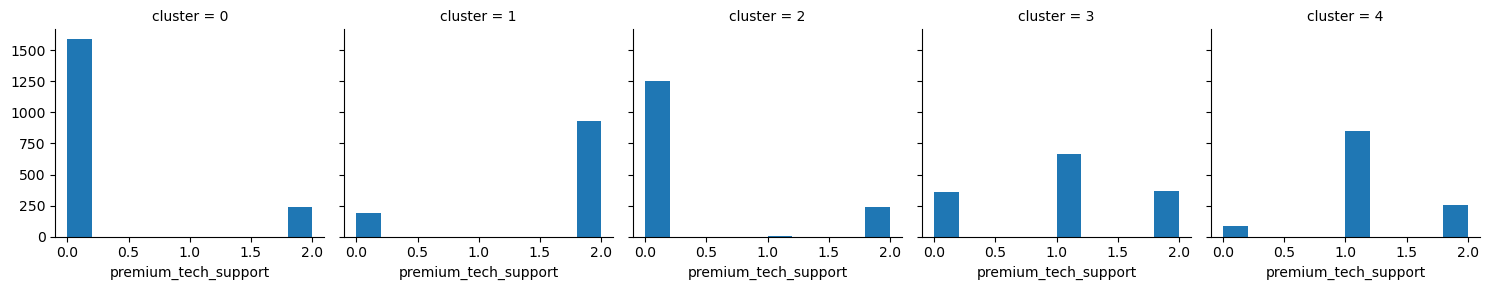

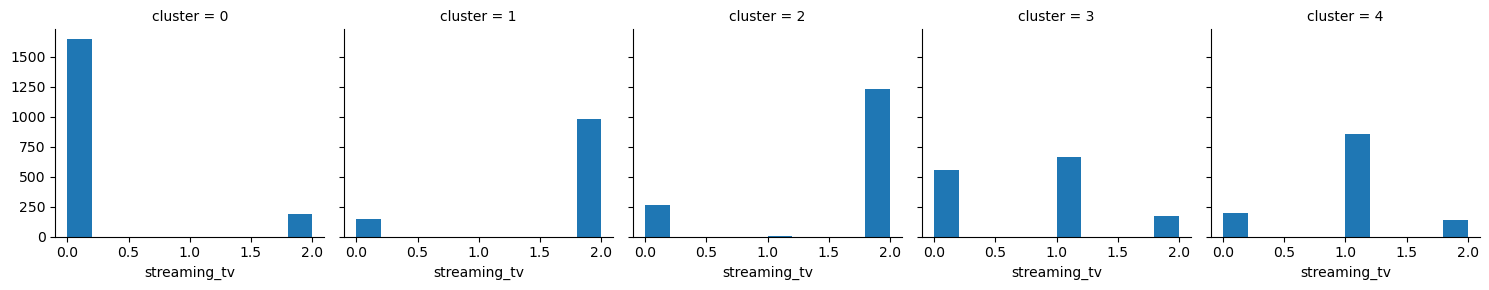

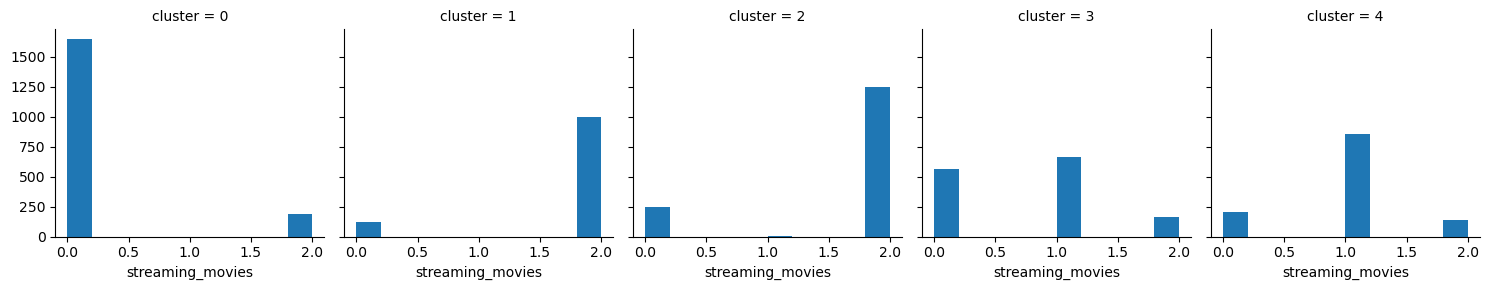

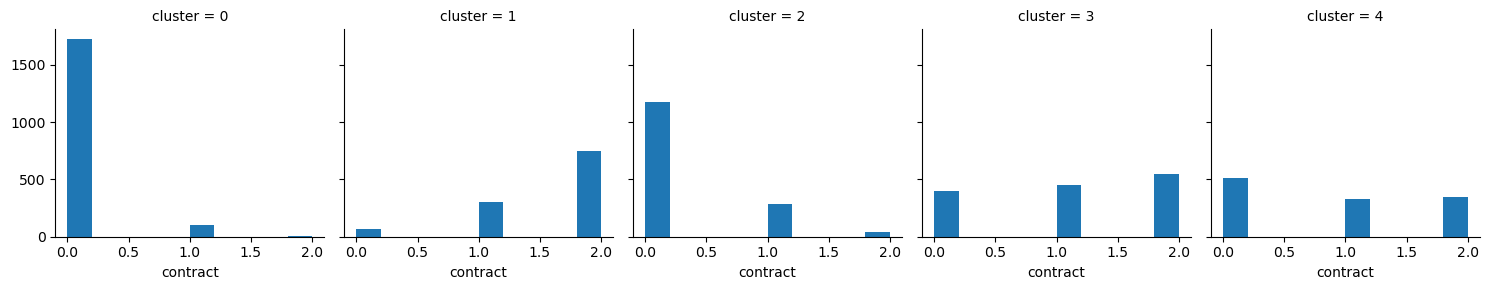

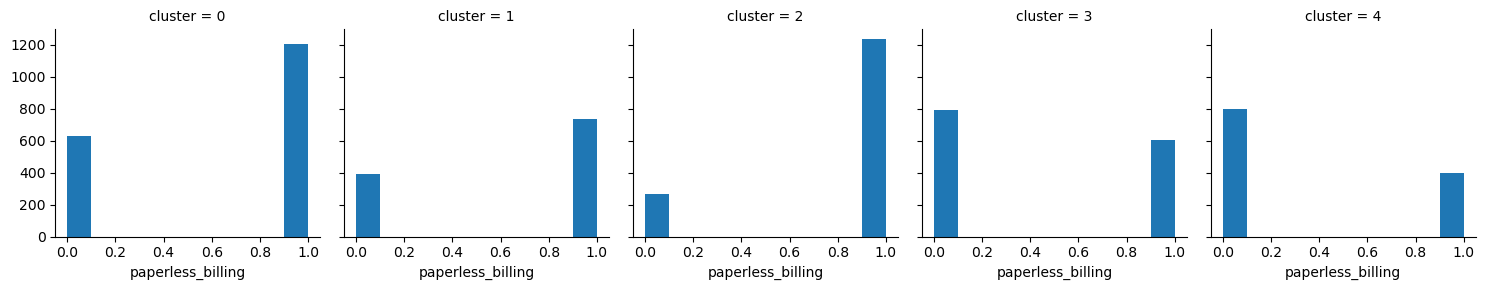

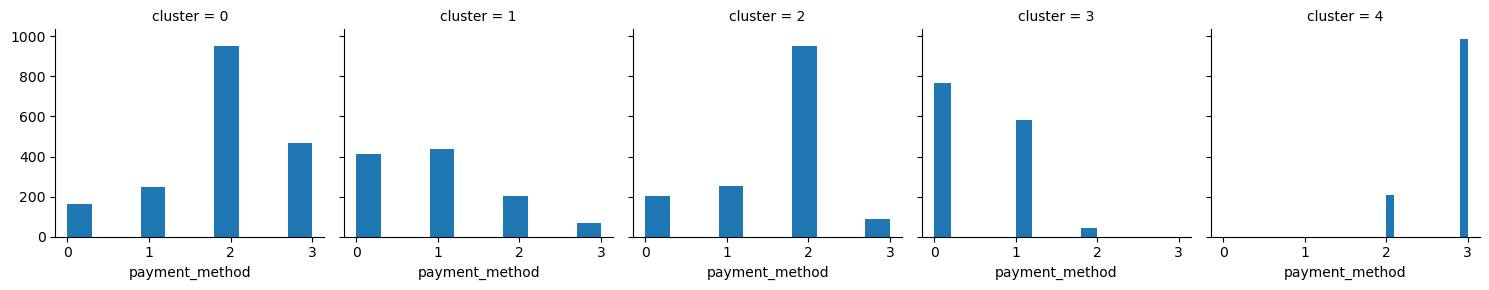

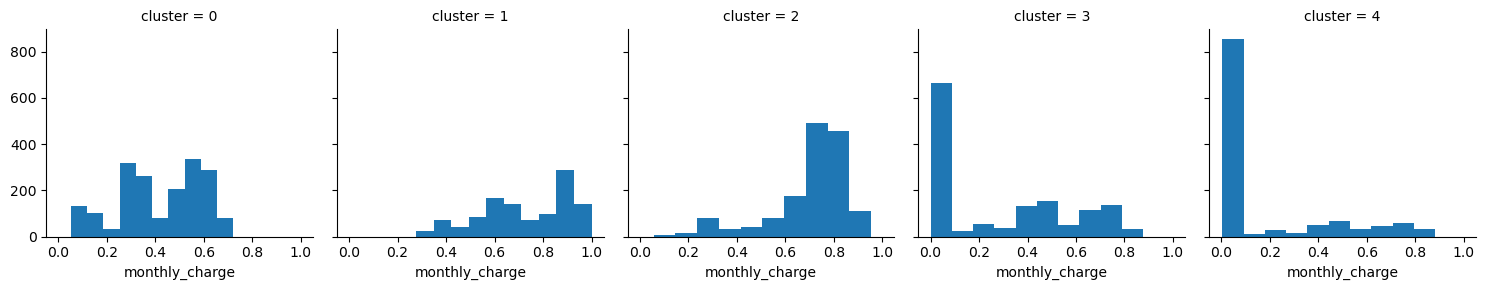

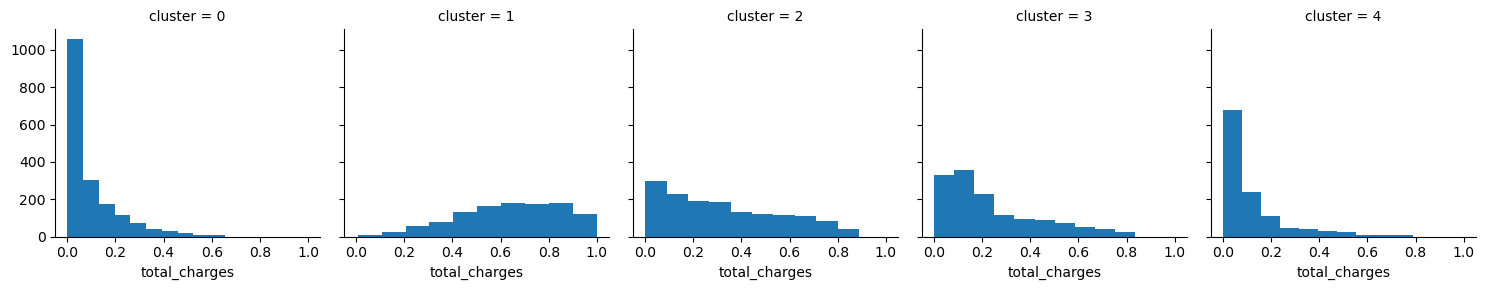

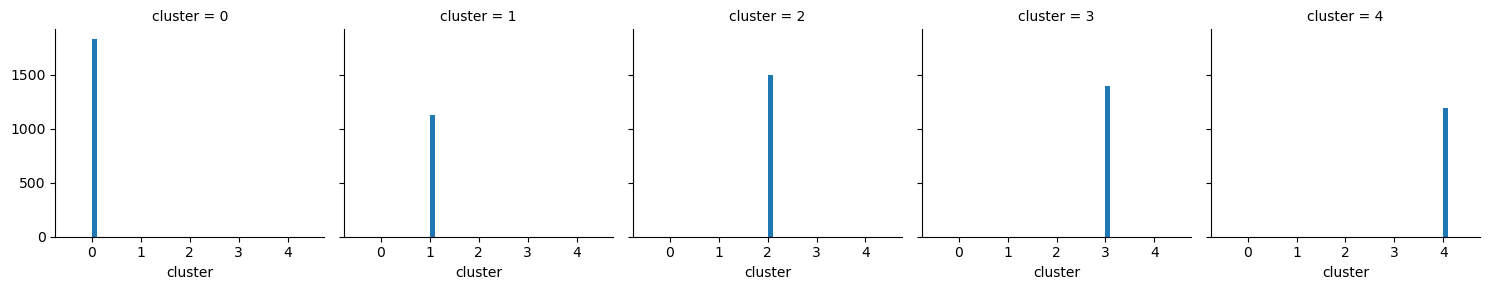

In [90]:
# Distribution des Variables par Cluster
for c in clusters:
    grid= sns.FacetGrid(clusters, col='cluster')
    grid.map(plt.hist, c)

La visualisation des différents clusters montrent que le cluster 4 est celui qui a le plus de données par rapport aux autre. Par conséquent nous allons considéré uniquement le cluster 4.

In [91]:
ciblage_metier=clusters.copy()

In [92]:
# Targeted cluster
cible = ciblage_metier[ciblage_metier.cluster == 4]
cible.head()

,gender,senior_citizen,married,dependents,tenure_in_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charge,total_charges,cluster
1,1,0,0,0,0.47,1,0,0,2,0,2,0,0,0,1,0,3,0.39,0.22,4
14,1,0,0,0,0.35,1,0,1,2,0,2,2,2,2,0,1,2,0.87,0.31,4
16,0,0,0,0,0.72,1,0,2,1,1,1,1,1,1,1,0,3,0.02,0.12,4
22,1,0,0,0,0.01,1,0,2,1,1,1,1,1,1,0,0,3,0.02,0.00,4
32,0,0,1,1,0.38,1,0,0,2,2,2,2,0,0,1,0,3,0.48,0.21,4


In [93]:
cible.shape

(1195, 20)

In [138]:
#Tri des données par ancienneté et frais mensuels 

segm = cible.sort_values(by = ['tenure_in_months', 'monthly_charge'], ascending = [True, False])
segm.head()

,gender,senior_citizen,married,dependents,tenure_in_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charge,total_charges,cluster
6670,0,0,1,1,0.00,1,2,0,0,2,2,2,2,0,2,0,3,0.55,0.26,4
6754,1,0,0,1,0.00,1,2,0,2,2,0,2,0,0,2,1,0,0.43,0.26,4
1340,0,0,1,1,0.00,0,1,0,2,2,2,2,2,0,2,0,1,0.38,0.26,4
488,0,0,1,1,0.00,0,1,0,2,0,2,2,2,0,2,1,0,0.34,0.26,4
1111,0,0,0,0,0.06,1,0,1,2,0,2,2,0,2,0,1,0,0.76,0.04,4


In [139]:
cibl = segm[0:800]

### Prédiction Ml 

### Keras model

In [140]:
# Extraction de la variable cible et des variables explicatives
y = df2[['churn_value']]
X = df2.drop(['churn_value'], axis=1)

In [141]:
# Imputation des valeurs manquantes dans 'total_charges' par la moyenne du dataframe X 

X['total_charges'].fillna(X['total_charges'].mean(), inplace=True)

In [142]:
# Application de SMOTE car l'ensemble de données est déséquilibré
smote = SMOTE(sampling_strategy ='minority')
X_sm ,y_sm = smote.fit_resample(X,y)

In [143]:
X_train,X_test,Y_train,Y_test = train_test_split(X_sm,y_sm,random_state =12,test_size =0.2,stratify=y_sm)

In [144]:
df2.columns

Index(['senior_citizen', 'dependents', 'tenure_in_months', 'internet_service',
       'online_security', 'premium_tech_support', 'contract',
       'paperless_billing', 'monthly_charge', 'total_charges', 'churn_value'],
      dtype='object')

#### Utilisation de la Forêt Aléatoire pour trouver les caractéristiques importantes

In [145]:
# Entraînement du modèle Random Forest et affichage 
rf= RandomForestClassifier()
rf.fit(X,y)
for name, score in zip(X.columns, rf.feature_importances_):
    print(name, score *100)

senior_citizen 1.9003893250189612
dependents 2.1083527648576674
tenure_in_months 18.00027209180271
internet_service 3.03512196986339
online_security 5.364778360655642
premium_tech_support 4.321901849286112
contract 9.517849470319476
paperless_billing 2.37338903161511
monthly_charge 26.4835846311896
total_charges 26.894360505391333


In [146]:
# Création et tri un DataFrame
datak = {'Features': X.columns , '%Importance': rf.feature_importances_ * 100 }
temp = pd.DataFrame(datak)
temp.sort_values(by = '%Importance',ascending = False)

,Features,%Importance
9,total_charges,26.89
8,monthly_charge,26.48
2,tenure_in_months,18.00
6,contract,9.52
4,online_security,5.36
5,premium_tech_support,4.32
3,internet_service,3.04
7,paperless_billing,2.37
1,dependents,2.11
0,senior_citizen,1.90


In [147]:
# Extraction des caractéristiques avec une importance inférieure à 2%
temp[temp['%Importance'] <2]['Features'].values

array(['senior_citizen'], dtype=object)

In [148]:
# Suppression de la colonne 'senior_citizen' des ensembles d'entraînement et de test
X_train.drop(columns = ['senior_citizen'], inplace = True)
X_test.drop(columns = ['senior_citizen'], inplace = True)

In [149]:
# Affichage des dimensions 
X_train.shape ,X_test.shape

((8278, 9), (2070, 9))

In [150]:
# Afficher le nombre de colonnes de X
print("Nombre de colonnes de X :", X.shape[1])


Nombre de colonnes de X : 10


In [151]:
# Construction du modèle de réseau de neurones avec Keras
model = Sequential()
model.add(Dense(45, activation = 'relu' , kernel_initializer ='he_uniform', input_dim = 9))
model.add(Dense(30 ,activation ='relu'))
model.add(Dropout(0.1))
model.add(Dense(10 ,activation ='relu'))
model.add(Dense(1,activation = 'sigmoid'))

In [152]:
# Compilation du modèle avec l'optimiseur Adam et la fonction de perte binary_crossentropy
model.compile(optimizer ='Adam' , loss ='binary_crossentropy' ,metrics =['accuracy'] )

In [153]:
# Affichage 
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 45)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         1,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,151 (8.40 KB)

 Trainable params: 2,151 (8.40 KB)

 Non-trainable params: 0 (0.00 B)

In [154]:
# Exécution du réseau de neurones artificiels pendant 100 époques
history = model.fit(X_train,Y_train , epochs = 50, validation_data = (X_test,Y_test))

Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6969 - loss: 0.5703 - val_accuracy: 0.7589 - val_loss: 0.4870
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7610 - loss: 0.4952 - val_accuracy: 0.7556 - val_loss: 0.4810
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7599 - loss: 0.4928 - val_accuracy: 0.7546 - val_loss: 0.4839
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7603 - loss: 0.4865 - val_accuracy: 0.7570 - val_loss: 0.4800
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7599 - loss: 0.4837 - val_accuracy: 0.7618 - val_loss: 0.4742
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7598 - loss: 0.4831 - val_accuracy: 0.7652 - val_loss: 0.4775
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7595 - loss: 0.4835 - val_accuracy: 0.7589 - val_loss: 0.4741
Epoch 8/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7701 - loss: 0.4763 - val_accuracy: 0.

In [155]:
# Résumé de l'historique de la précision
plt.figure(figsize=(10, 7))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('ANN accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Apprentissage Automatisé (AutoML) avec des Données SMOTE

In [156]:
# Entraînement et prédiction avec AutoML

from supervised.automl import AutoML
automl = AutoML()
automl.fit(X_train, Y_train)

predictions = automl.predict(X_test)

AutoML directory: AutoML_12
The task is binary_classification with evaluation metric logloss
AutoML will use algorithms: ['Baseline', 'Linear', 'Decision Tree', 'Random Forest', 'Xgboost', 'Neural Network']
AutoML will ensemble available models
AutoML steps: ['simple_algorithms', 'default_algorithms', 'ensemble']
* Step simple_algorithms will try to check up to 3 models
invalid value encountered in divide
1_Baseline logloss 0.693147 trained in 1.44 seconds
2_DecisionTree logloss 0.503006 trained in 37.02 seconds
3_Linear logloss 0.477066 trained in 6.8 seconds
* Step default_algorithms will try to check up to 3 models
4_Default_Xgboost logloss 0.429713 trained in 5.21 seconds
5_Default_NeuralNetwork logloss 0.474212 trained in 5.28 seconds
6_Default_RandomForest logloss 0.466898 trained in 4.86 seconds
* Step ensemble will try to check up to 1 model
Ensemble logloss 0.425531 trained in 2.56 seconds
AutoML fit time: 74.93 seconds
AutoML best model: Ensemble


### Réechantillonnage et modélisation

In [157]:
# Application de SMOTE et affichage de la distribution des classes
over = SMOTE(sampling_strategy = 1)

f1 = X.values
t1 = y.values

f1, t1 = over.fit_resample(f1, t1)
Counter(t1)

Counter({0: 5174, 1: 5174})

In [158]:
# Séparation des données en ensembles d'entraînement et de test
x_train, x_test, y_train, y_test = train_test_split(f1, t1, test_size = 0.20, random_state = 2)

In [159]:
# Affichage
x_train.shape, x_test.shape

((8278, 10), (2070, 10))

#### Lazy Classifier

In [160]:
# Entraînement des modèles de classification et affichage des résultats
clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(x_train, x_test, y_train, y_test)

models

100%|██████████| 31/31 [00:16<00:00,  1.93it/s]


[LightGBM] [Info] Number of positive: 4144, number of negative: 4134
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 8278, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500604 -> initscore=0.002416
[LightGBM] [Info] Start training from score 0.002416


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
XGBClassifier,0.82,0.82,0.82,0.82,0.15
LGBMClassifier,0.82,0.82,0.82,0.82,0.19
RandomForestClassifier,0.81,0.81,0.81,0.81,1.19
ExtraTreesClassifier,0.80,0.80,0.80,0.80,1.01
BaggingClassifier,0.79,0.79,0.79,0.79,0.36
KNeighborsClassifier,0.78,0.78,0.78,0.78,0.19
ExtraTreeClassifier,0.77,0.77,0.77,0.77,0.06
DecisionTreeClassifier,0.77,0.77,0.77,0.77,0.12
AdaBoostClassifier,0.77,0.77,0.77,0.77,0.51


Sur la base des résultats obtenus,l'algorithme XGBClassifier a montré une performance supérieure par rapport aux autres modèles évalués, avec des scores élevés en précision, rappel et F1.

In [161]:
# Affichage du Meilleur Score parmi les Modèles
models.max() 

Accuracy            0.82
Balanced Accuracy   0.82
ROC AUC             0.82
F1 Score            0.82
Time Taken          4.64
dtype: float64

In [162]:
# Évaluation et Analyse du Modèle de Classification

def model(classifier,x_train,y_train,x_test,y_test):
    
    classifier.fit(x_train,y_train)
    prediction = classifier.predict(x_test)
    cv = RepeatedStratifiedKFold(n_splits = 10,n_repeats = 3,random_state = 1)
    print("Cross Validation Score : ",'{0:.2%}'.format(cross_val_score(classifier,x_train,y_train,cv = cv,scoring = 'roc_auc').mean()))
    print("ROC_AUC Score : ",'{0:.2%}'.format(roc_auc_score(y_test,prediction)))


def model_evaluation(classifier,x_test,y_test):
    
    # Confusion Matrix
    cm = confusion_matrix(y_test,classifier.predict(x_test))
    names = ['True Neg','False Pos','False Neg','True Pos']
    counts = [value for value in cm.flatten()]
    percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(names,counts,percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cm,annot = labels,cmap = 'Blues',fmt ='')
    
    # Classification Report
    print(classification_report(y_test,classifier.predict(x_test)))

Application du model XGBoost

In [163]:
# Initialisation du Classificateur XGBoost
classifier_xgb = XGBClassifier()

In [164]:
# Évaluation du Modèle XGBoost
model(classifier_xgb,x_train,y_train,x_test,y_test)

Cross Validation Score :  88.77%
ROC_AUC Score :  81.56%


Le modèle XGBoost obtient un excellent score post cross validation de 88.77% et un score AUC ROC de 81.56% indiquant une grande capacité à discriminer entre les classes et une bonne généralisation des données.

In [165]:
# Évaluation du Modèle XGBoost sur les Données de Test
model_evaluation(classifier_xgb,x_test,y_test)

              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1040
           1       0.80      0.85      0.82      1030

    accuracy                           0.82      2070
   macro avg       0.82      0.82      0.82      2070
weighted avg       0.82      0.82      0.82      2070



In [166]:
# Prédiction des Classes avec le Modèle XGBoost sur les Données de Test
y_pred_xg = classifier_xgb.predict(x_test)

In [167]:
# Calcul et Visualisation de la Courbe Précision-Rappel et du Score F1

# Calcul de la Courbe Précision-Rappel
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_xg)
# Calcul du Score F1
score_f1 = metrics.f1_score(y_test, y_pred_xg)
print('score_f1=%.3f' % (score_f1))
# Tracé de la Courbe de Référence 
plt.plot([0, 1], [0.5, 0.5], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.show()

score_f1=0.820


Ce score montre que le modèle est efficace en équilibrant précision et rappel pour une classification solide.

### La courbe de lif

In [168]:
# Calcul et Visualisation de la Courbe de Lift 
def lift_curve_data(y_true, y_pred):

    sorted_score = np.argsort(y_pred)[::-1]
    
    # Vérifier que y_true et y_pred sont des tableaux
    if not isinstance(y_true, np.ndarray):
        y_true = y_true.to_numpy()
    if not isinstance(y_pred, np.ndarray):
        y_pred = y_pred.to_numpy()
        
    y_true = y_true[sorted_score]
    y_pred = y_pred[sorted_score]

    # Creation d'un DataFrame contenant les deux vecteurs : lift_df
    # Nommons les colonnes en y_pred et y_true
    lift_df = pd.DataFrame({"y_pred": y_pred, "y_true": y_true})

    # Divisons le jeu de données en quantiles (percentiles ici) : perc_bins

    lift_df["perc"] = (lift_df.index / lift_df.shape[0]) * 100
    lift_df["perc_bins"] = pd.cut(lift_df["perc"], np.arange(0, 101, 1))

    # Groupement par intervalle et calcul du nombre de y = 1
    lift_df = (lift_df.groupby(["perc_bins"], as_index=False)
               .agg(y_true_sum=("y_true", "sum"))
              )
    # Calcul du nombre cumulatif de y = 1 : y_true_cumsum
    lift_df["y_true_cumsum"] = lift_df["y_true_sum"].cumsum()

    # Calcul de la concentration (ratio de y_true_cumsum par le total de y = 1) : concentration
    lift_df["concentration"] = (lift_df["y_true_cumsum"] / lift_df["y_true_sum"].sum())*100

   # Ajout d'un point avec les coordonnées (0, 0) sur la première ligne.
   
    zeros_df = pd.DataFrame(np.zeros((1, 4)), columns=lift_df.columns)
    lift_df = pd.concat([zeros_df, lift_df]).reset_index(drop=True)
    
    return lift_df

In [169]:
# Représentation de la courbe de lift
# Prédire sur l'ensemble de test
y_pred = classifier_xgb.predict_proba(x_test)[:, 1]

# Construisons le jeu de données pour la courbe
lift_df = lift_curve_data(y_true=y_test, y_pred=y_pred)

# Affichons la courbe
fig = go.Figure()
fig.add_shape(
    type="line", line=dict(dash="dash"),
    x0=0, x1=100, y0=0, y1=100
)
fig.add_trace(
    go.Scatter(
        x=lift_df.index,
        y=lift_df["concentration"],
        mode="lines"
    )
)
fig.update_layout(
    xaxis_title="% des clients classés par ordre de scores décroissants",
    yaxis_title="% de la cible",
    yaxis=dict(scaleanchor="x", scaleratio=1),
    xaxis=dict(constrain="domain"),
    margin=dict(l=0, r=0, t=30, b=50),
    width=600, height=400
)
fig.show()


Les résultats de la courbe de Lift montre que cibler 22% des clients classés par ordre de score décroissants permet de toucher 41.49% de la cible.

Pour Cette courbe 

In [170]:
# Courbe de lift avec scikitplot
plt.figure(figsize=(8,8))
skplt.metrics.plot_cumulative_gain(
    y_true=y_test,
    y_probas=classifier_xgb.predict_proba(x_test)
)
plt.show()

#### Score de Spiegelhalter et Courbe de Calibration

In [171]:
# Calcul du score de Spiegelhalter

def score_spiegelhalter(y_true, y_pred):
    numerateur = np.sum(np.multiply(y_true - y_pred, 1 - 2 * y_pred))
    denominateur = np.sqrt(
        np.sum(
            np.multiply(
                np.multiply(np.power(1 - 2 * y_pred, 2), y_pred), 1 - y_pred
            )
        )
    )
    
    return numerateur / denominateur

In [172]:
y_pred = classifier_xgb.predict_proba(x_test)[:, 1]
score_spiegelhalter(y_test, y_pred)

1.962257176873332

Le score est de 1,962, ce qui indique que le modèle est plutôt bien calibré. Cependant, il serait toujours utile pour nous de vérifier la courbe de calibration pour confirmer cette évaluation et détecter d'éventuels points aberrants qui pourraient influencer le score . 

In [173]:
# Calcul de la Courbe de Calibration 
 
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

def sklearn_calibration(y_true, y_pred, n_bins=20):
    
    prob_true, prob_pred = calibration_curve(
        y_true, y_pred,
        n_bins=n_bins,
        strategy="quantile"
    )
    
    df = pd.DataFrame({"prob_pred":prob_pred, "prob_true":prob_true})
    
    return df

In [174]:
# Prédiction sur le jeu de données de tes
y_pred = classifier_xgb.predict_proba(x_test)[:, 1]

# Construction du tableau de données
sklearn_calibration_df = sklearn_calibration(y_test, y_pred)

# Affichage graphique
xlim_ylim_sklearn = sklearn_calibration_df.values.max()

fig = px.scatter(
    sklearn_calibration_df,
    x="prob_pred",
    y="prob_true"
)
fig.add_trace(
    go.Scatter(
        x=[0, xlim_ylim_sklearn],
        y=[0, xlim_ylim_sklearn],
        mode="lines",
        line=go.scatter.Line(color="gray"),
        showlegend=False)
)
fig.update_layout(
    xaxis_title="Moyenne des probabilités",
    yaxis_title="Proportion des positifs (y = 1)",
    yaxis=dict(scaleanchor="x", scaleratio=1),
    xaxis=dict(constrain='domain'),
    margin=dict(l=0, r=0, t=30, b=50),
    width=600, height=400
)
fig.show()

L'observation de la courbe de calibration montre que laplupart des points sont sur ou très proche de la ligne médiane confirmant la valeur du score de Spiegelhalter.

In [195]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import os

# Importances des caractéristiques
importances = classifier_xgb.feature_importances_

# Remplacez par les caractéristiques
feature_names = ['senior_citizen',	'dependents',	'tenure_in_months',	'internet_service',	'online_security',	'premium_tech_support',	'contract',	'paperless_billing',	'monthly_charge',	'total_charges']  # Exemple

# Vérifiez les tailles
if len(importances) != len(feature_names):
    raise ValueError(f"Le nombre d'importances ({len(importances)}) ne correspond pas au nombre de caractéristiques ({len(feature_names)}).")

# Visualisons les importances
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances, tick_label=feature_names)
plt.xlabel('Caractéristiques')
plt.ylabel('Importance')
plt.title('Importances des Caractéristiques pour XGBoost')
plt.xticks(rotation=90)

# Chemin du dossier pour l'enregistrement 
output_dir = 'C:/Users/LENOVO THINKPAD T480/Desktop/Machine learning'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Chemin complet du fichier
output_path = os.path.join(output_dir, 'importances_xgboost.png')

# Enregistrement le graphique
plt.savefig(output_path, bbox_inches='tight')

# Affichons le graphique
plt.show()

print(f"Graphique enregistré sous : {output_path}")


Graphique enregistré sous : C:/Users/LENOVO THINKPAD T480/Desktop/Machine learning\importances_xgboost.png


In [197]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Chemin de mon fichier
image_path = 'C:/Users/LENOVO THINKPAD T480/Desktop/Machine learning/importances_xgboost.png'  # Remplacez par le chemin réel de votre fichier

# Chargeons l'image
img = mpimg.imread(image_path)

# Affichons l'image
plt.imshow(img)
plt.axis('off')  # Optionnel : désactivez les axes si vous ne voulez pas les afficher
plt.show()


Notre travail nous indiquent que les determinants qui influence le plus le churn sont en premier lieu le contrat en deuxième lieu les services internet en troisième lieu le support tech premium  ( cest à dire les services d'assistance technique haut niveau),et enfin nous avons la variable Online Security.